# Final figures — cross-sectional OTC resection manuscript

Merged from `figures_harmonized__2_.ipynb`, `patients_figures_clean.ipynb`, and
`tfce_cluster_figure_trimmed.ipynb`. Run top to bottom on the cluster.

**Figure set.** The six figures in `only_figs.docx`, plus the three additions:
peak selectivity, Procrustes/MDS geometry, and the TFCE surface figure with Table 2.

**What changed in the merge**

| | |
|---|---|
| `plot_primary_panel` | now takes `q_map`; the peak-selectivity call failed with `TypeError` before |
| params | `from params import processed_dir` only — `sym_pt_params` is not imported |
| TFCE run | `tfce_votc_harmonized` (harmonized is primary). The `tfce_votc_fdr` reference came in with the stacked-WTA cell, which is not in this figure set |
| TFCE surfaces | inflated (`infl_*`), `kind='line'` / `interpolation='linear'` / vertex threshold 0.3 — no connected-component floor |
| session/exclusion filtering | one `load_harmonized()` instead of seven copies |
| `coords` | split into `peak_xy()` (MNI peak scatter) and `mds_coords()` (MDS embedding) — the two source notebooks gave the same name to different functions |
| MDS source | `rsa_v1_harmonized.csv`, matching §7/§8. The pasted cell read unharmonized `fisher_r` from `peak_coords_mni.csv`, so these panels will differ from that version |
| MDS source | §9 now reads harmonized `fisher_r` from `rsa_v1_harmonized.csv`; it previously read the unharmonized `fisher_r` from `peak_coords_mni.csv`, and used `house_PPA` instead of `house_PPA_strict` |
| defined once | `CAT_COLORS`, `CATEGORIES`, `EXCLUDE_SES`, `RSA_HARM`, `ROI_ORDER`/`ROI_TITLE`/`ROI_CAT`, `SLOTS`, `stars`, `tint`, `shade`, `stratum` |
| dropped | sum-selectivity panel (retired), the older distinctiveness panel, the single-row between-category panel, the duplicate Procrustes cell, WTA bars, stacked within-cluster WTA, PPA-parcel and rVWFA-adjacency diagnostics, CLR sensitivity print |

**Two things to check on the first run** — each prints its own answer:
1. `STATS['measure'].unique()` (Config cell). Stars for peak selectivity and
   selective voxels need `peak_selectivity` and `selective_voxels` rows in
   `stats_results_harmonized_corrected.csv`; each panel prints how many q cells resolved.
2. §8 prints the q values resolved from `STATS_CSV` beside the four values that
   were hardcoded in the source cell. Set `USE_STATS_Q = False` in that cell to
   fall back to the hardcoded set.

## 0 · Config — paths, cohort, style

In [2]:
# ─── Config: single source of truth ──────────────────────────────────────
import sys
import colorsys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Ellipse

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from params import processed_dir          # params.py only (superset); sym_pt_params unused

REPO = Path('/user_data/csimmon2/git_repos/sym_pt')
BASE = Path(processed_dir)

STATS_CSV   = REPO / 'D_liu' / 'stats_results_harmonized_corrected.csv'
UNIVAR_SQRT = REPO / 'D_liu' / 'univariate_v1_harmonized_sqrt.csv'   # combat_05b: peak_z + volume
RSA_HARM    = REPO / 'D_liu' / 'rsa_v1_harmonized.csv'
SUB_INFO    = REPO / 'sub_info.csv'
MNI_CSV     = BASE / 'group_results' / 'peak_coords' / 'peak_coords_mni.csv'
TFCE_DIR    = BASE / 'group_results' / 'tfce_votc_harmonized'        # harmonized = primary
FIG_DIR     = REPO / 'C_results' / 'figures' / 'liu_exact'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Must match EXCLUDE in D_liu/verified/05_stats_harmony.py.
EXCLUDE     = ['sub-017',                        # polymicrogyria
               'sub-091', 'sub-095', 'sub-096',  # age cap <= 23
               'sub-027', 'sub-084']             # control exclusions
EXCLUDE_SES = [('sub-108', 2)]
AGE_CAP     = 23.0

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}

HOUSE_ROI   = 'house_PPA_strict'                 # primary house parcel
CAT_PRIMARY = {'face': 'face_FFA', 'house': HOUSE_ROI,
               'object': 'object_LOC', 'word': 'word_VWFA'}
ROI_CAT     = {v: k for k, v in CAT_PRIMARY.items()}
ROI_ORDER   = ['word_VWFA', 'face_FFA', HOUSE_ROI, 'object_LOC']
ROI_TITLE   = {'word_VWFA': 'VWFA', 'face_FFA': 'FFA',
               HOUSE_ROI: 'PPA', 'object_LOC': 'LO'}

PAIRS_ORDERED = ['face-word', 'house-word', 'object-word',
                 'face-house', 'face-object', 'house-object']
CATS4  = ['face', 'object', 'house', 'word']     # MDS matrix order; subj_rdm indexes on this
PAIRS6 = [('face', 'object'), ('face', 'house'), ('face', 'word'),
          ('house', 'object'), ('object', 'word'), ('house', 'word')]

# ctrl L, ctrl R, pt L, pt R — shared x geometry for the box panels (§6, §7)
SLOTS = [('ctrl L', 0.00, 'l', 0.22), ('ctrl R', 0.55, 'r', 0.50),
         ('pt L',   1.35, 'l', 0.22), ('pt R',   1.90, 'r', 0.50)]

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False})

for _p in (STATS_CSV, UNIVAR_SQRT, RSA_HARM, SUB_INFO, MNI_CSV, TFCE_DIR):
    print(f'{"ok      " if _p.exists() else "MISSING "}{_p}')

ok      /user_data/csimmon2/git_repos/sym_pt/D_liu/stats_results_harmonized_corrected.csv
ok      /user_data/csimmon2/git_repos/sym_pt/D_liu/univariate_v1_harmonized_sqrt.csv
ok      /user_data/csimmon2/git_repos/sym_pt/D_liu/rsa_v1_harmonized.csv
ok      /user_data/csimmon2/git_repos/sym_pt/sub_info.csv
ok      /user_data/csimmon2/sym_pt/group_results/peak_coords/peak_coords_mni.csv
ok      /user_data/csimmon2/sym_pt/group_results/tfce_votc_harmonized


## 1 · Shared helpers and loader
`load_harmonized()` replaces the seven copies of the exclusion + session-selection block that were spread across the source notebooks. Controls take their first session, OTC patients their last.

In [3]:
# ─── Helpers ─────────────────────────────────────────────────────────────
def stars(q):
    """BH-FDR q -> asterisks. Empty string for NaN/None/non-significant."""
    if q is None or pd.isna(q):
        return ''
    return '***' if q < .001 else '**' if q < .01 else '*' if q < .05 else ''


def _rgb(hexc):
    hexc = hexc.lstrip('#')
    return [int(hexc[i:i + 2], 16) / 255 for i in (0, 2, 4)]


def _hex(r, g, b):
    return '#%02X%02X%02X' % (int(r * 255), int(g * 255), int(b * 255))


def shade(hexc, f):
    """Scale lightness by f (<1 darker, >1 lighter)."""
    h, l, s = colorsys.rgb_to_hls(*_rgb(hexc))
    return _hex(*colorsys.hls_to_rgb(h, max(0, min(1, l * f)), s))


def _merge_age(d):
    si = pd.read_csv(SUB_INFO)
    si['subject_id'] = si['sub'].astype(str)
    si['ses_num'] = pd.to_numeric(
        si['ses'].astype(str).str.extract(r'(\d+)', expand=False), errors='coerce')
    si = (si[['subject_id', 'ses_num', 'age']].dropna()
            .drop_duplicates(['subject_id', 'ses_num']))
    si['ses_num'] = si['ses_num'].astype(int)
    d = d.drop(columns=[c for c in ('age',) if c in d.columns])
    return d.merge(si, on=['subject_id', 'ses_num'], how='left')


def load_harmonized(path, label, collapse_pairs=False, drop_negative=None,
                    age_cap=None, intact_only=True):
    """EXCLUDE + EXCLUDE_SES applied, controls -> first session, OTC -> last.

    collapse_pairs  drop the long-by-pair columns and dedupe (RSA files)
    drop_negative   drop rows where this column is < 0 (ComBat sqrt residuals)
    age_cap         merge age from sub_info.csv and cap; prints who it drops
    intact_only     restrict patients to rows in their intact hemisphere
    """
    d = pd.read_csv(path)
    d = d[d['group'].isin(['OTC', 'control'])]
    d = d[~d['subject_id'].isin(EXCLUDE)].copy()
    d['ses_num'] = pd.to_numeric(d['session'], errors='coerce').astype(int)
    for bad_sub, bad_ses in EXCLUDE_SES:
        d = d[~((d['subject_id'] == bad_sub) & (d['ses_num'] == bad_ses))]

    if drop_negative is not None:
        n0 = len(d)
        d = d[d[drop_negative] >= 0]
        print(f'  {label}: dropped {n0 - len(d)} rows with {drop_negative} < 0')
    if collapse_pairs and 'pair' in d.columns:
        d = d.drop(columns=['pair', 'fisher_r']).drop_duplicates()
    if age_cap is not None:
        d = _merge_age(d)
        over = sorted(d.loc[d['age'] > age_cap, 'subject_id'].unique())
        miss = sorted(d.loc[d['age'].isna(), 'subject_id'].unique())
        print(f'  {label}: above cap {age_cap:g} after EXCLUDE -> {over or "none"}'
              f' | no age row in sub_info -> {miss or "none"}')
        d = d[d['age'] <= age_cap]

    ctrl = d[d['status'] == 'control'].copy()
    ctrl = ctrl[ctrl['ses_num'] == ctrl.groupby('subject_id')['ses_num'].transform('min')]
    pt = d[d['group'] == 'OTC'].copy()
    pt = pt[pt['ses_num'] == pt.groupby('subject_id')['ses_num'].transform('max')]
    if intact_only:
        pt = pt[pt['hemi'] == pt['intact_hemi'].map({'left': 'l', 'right': 'r'})]

    by = pt.groupby('intact_hemi')['subject_id'].nunique().to_dict()
    print(f'{label}: ctrl n={ctrl.subject_id.nunique()}  '
          f'pt n={pt.subject_id.nunique()}  {by}')
    return ctrl, pt

In [4]:
# ─── Load once ───────────────────────────────────────────────────────────
STATS = pd.read_csv(STATS_CSV)
print('measures   :', sorted(STATS['measure'].astype(str).unique()))
print('comparisons:', sorted(STATS['comparison'].astype(str).unique()))
print()

# RSA: long by pair for the geometry panels, collapsed for distinctiveness
rsa_c_long, rsa_p_long = load_harmonized(RSA_HARM, 'rsa long (by pair)')
rsa_c = rsa_c_long.drop(columns=['pair', 'fisher_r']).drop_duplicates()
rsa_p = rsa_p_long.drop(columns=['pair', 'fisher_r']).drop_duplicates()

# Univariate: peak_z, then volume with the ComBat sqrt-scale negatives dropped
peak_c, peak_p = load_harmonized(UNIVAR_SQRT, 'univariate peak_z', age_cap=AGE_CAP)
vox_c,  vox_p  = load_harmonized(UNIVAR_SQRT, 'univariate volume',
                                 drop_negative='volume', age_cap=AGE_CAP)

measures   : ['distinctiveness', 'geometry', 'peak_distance', 'peak_selectivity', 'selective_voxels', 'sum_selectivity', 'wta', 'wta_selective_prop', 'wta_within_cluster']
comparisons: ['control_asymmetry', 'descriptive', 'group_main_effect', 'omnibus', 'patient_subgroup', 'patient_vs_control']

rsa long (by pair): ctrl n=36  pt n=24  {'left': 12, 'right': 12}
  univariate peak_z: above cap 23 after EXCLUDE -> none | no age row in sub_info -> none
univariate peak_z: ctrl n=36  pt n=24  {'left': 12, 'right': 12}
  univariate volume: dropped 33 rows with volume < 0
  univariate volume: above cap 23 after EXCLUDE -> none | no age row in sub_info -> none
univariate volume: ctrl n=36  pt n=24  {'left': 12, 'right': 12}


## 2 · Patient cohort — timeline, metadata, scan age, surgery type
Panels A–D. Reads `sub_info.csv` for the control age strip; patient rows are the hardcoded `LH`/`RH` tables below.

controls: 38 -> 36 after age cap <= 23


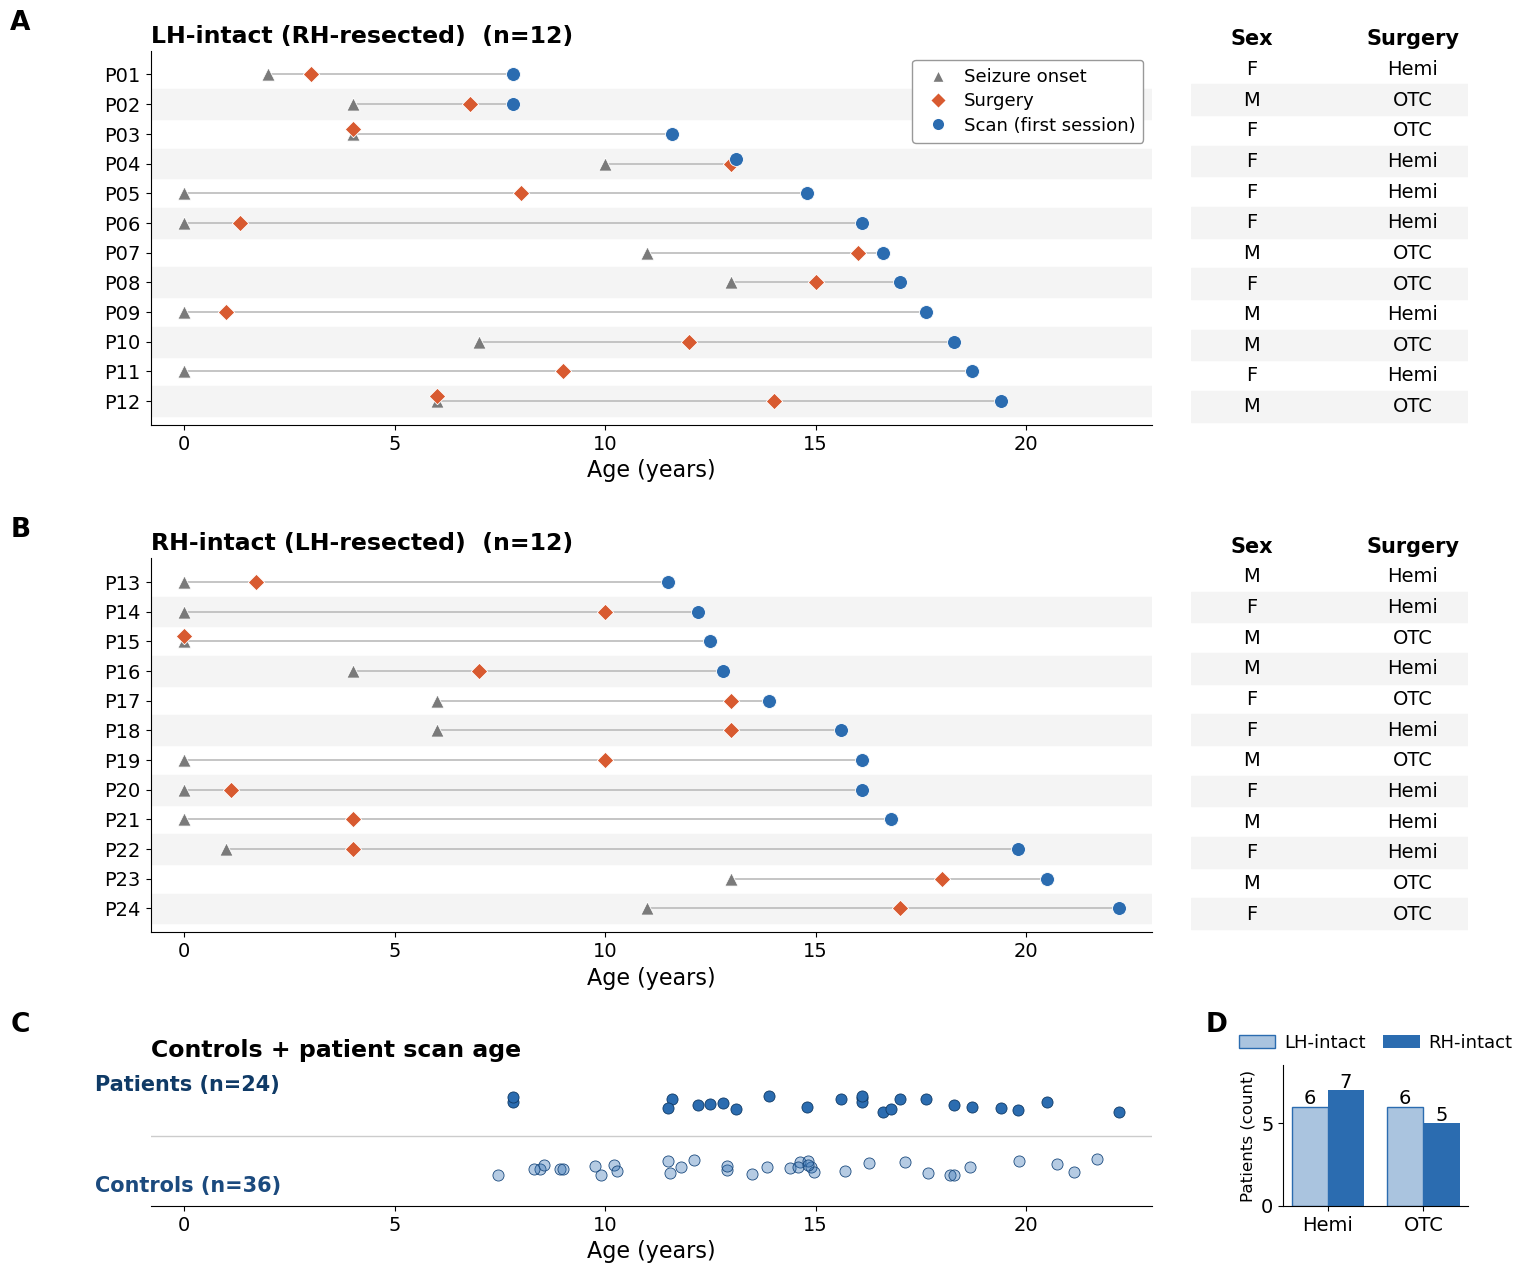

In [5]:
#!/usr/bin/env python
"""
Full cross-sectional figure, one canvas:
  A  LH-intact (RH-resected): timeline + metadata table
  B  RH-intact (LH-resected): timeline + metadata table
  C  Controls + patient scan age (jittered strip)
  D  Surgery type by hemisphere

AGE CAP <= 23 applied. Removes P13 (scan 37.3, = sub-091) and controls
sub-095 (38.5) and sub-096 (27.9). Those three were the only reason for the
37y axis break, so the break axes (axLb/axRb/axSb), the split() helper and the
diagonal break marks are gone. Cohort is now 12 LH-intact / 12 RH-intact and
34 controls.
"""

from matplotlib import gridspec

CSV = str(SUB_INFO)              # from Config
CTRL_EXCLUDE = {"sub-027","sub-084"}

C_SCAN  = "#2B6CB0"
C_EDGE_C= "#1B4A7E"
C_EDGE_P= "#0F3A66"
C_SEIZ, C_SURG = "#7A7A7A", "#D85A30"
LINE, BAND = "#BBBBBB", "#F4F4F4"
C_LH_BAR = (0.169, 0.424, 0.690, 0.40)   # translucent C_SCAN
AGE_MAX = 23
rng = np.random.default_rng(7)

# (pid, sex, surgery, seizure, surgery_age, scan)
LH = [
    ("P01","F","Hemi",  2.0,  3.0,   7.8),
    ("P02","M","OTC",   4.0,  6.8,   7.8),   # = sub-004 (UD in Liu 2025); surgery 6y9m
    ("P03","F","OTC",   4.0,  4.0,  11.6),
    ("P04","F","Hemi", 10.0, 13.0,  13.1),
    ("P05","F","Hemi",  0.0,  8.0,  14.8),
    ("P06","F","Hemi",  0.0,  1.33, 16.11),
    ("P07","M","OTC",  11.0, 16.0,  16.6),
    ("P08","F","OTC",  13.0, 15.0,  17.0),
    ("P09","M","Hemi",  0.0,  1.0,  17.62),
    ("P10","M","OTC",   7.0, 12.0,  18.3),
    ("P11","F","Hemi",  0.0,  9.0,  18.71),
    ("P12","M","OTC",   6.0,(6.0,14.0),19.4),
]
RH = [
    ("P13","M","Hemi",  0.0,  1.7, 11.5),
    ("P14","F","Hemi",  0.0, 10.0, 12.2),
    ("P15","M","OTC",   0.0,  0.0, 12.5),
    ("P16","M","Hemi",  4.0,  7.0, 12.8),
    ("P17","F","OTC",   6.0, 13.0, 13.9),
    ("P18","F","Hemi",  6.0, 13.0, 15.6),
    ("P19","M","OTC",   0.0, 10.0, 16.1),
    ("P20","F","Hemi",  0.0,  1.1, 16.1),
    ("P21","M","Hemi",  0.0,  4.0, 16.8),
    ("P22","F","Hemi",  1.0,  4.0, 19.8),
    ("P23","M","OTC",  13.0, 18.0, 20.5),
    ("P24","F","OTC",  11.0, 17.0, 22.2),
]
assert len(LH) == 12
assert len(RH) == 12
PT_SCAN = np.array([r[5] for r in LH+RH])
assert PT_SCAN.max() <= AGE_CAP, "a patient is above the age cap"

# The plotted scan must follow at least one surgery. Patients with more than
# one operation (surgery_age given as a tuple) can legitimately have a later
# surgery after the scan, so the check is against the EARLIEST surgery.
_su = lambda v: [x for x in (list(v) if isinstance(v,(tuple,list)) else [v])
                 if x is not None]
_bad = [(r[0], _su(r[4]), r[5]) for r in LH+RH if min(_su(r[4])) > r[5]]
if _bad:
    print("WARNING scan precedes all recorded surgeries:",
          ", ".join(f"{p} surgery {s} > scan {c}" for p,s,c in _bad))
COLX = {"Sex":0.22, "Surgery":0.80}

FS_TICK=14; FS_CELL=14; FS_HEADER=15; FS_TITLE=17; FS_XLAB=16; FS_NLAB=15
FS_LETTER=19; FS_LEGEND=13; FS_DLAB=15


def bands(ax, n):
    for r in range(n):
        if r % 2 == 0: ax.axhspan(r-0.5, r+0.5, color=BAND, zorder=0)


def panel_letter(ax, L, dx=-0.12, dy=1.04):
    ax.text(dx, dy, L, transform=ax.transAxes, fontsize=FS_LETTER, fontweight="bold",
            va="bottom", ha="right")


def draw_timeline(ax, rows):
    """One row per patient. Events at the same age are offset vertically so
    seizure onset, surgery and scan do not overlap."""
    n=len(rows); bands(ax,n)
    JIT, WIN = 0.16, 0.6          # vertical offset; collision window in years
    for i,row in enumerate(rows):
        pid,_,_,sz,su,sc=row; y=n-1-i
        su_list=[v for v in (list(su) if isinstance(su,(tuple,list)) else [su])
                 if v is not None]
        ax.plot([min([sz]+su_list+[sc]), max([sz]+su_list+[sc])],[y,y],
                color=LINE,lw=1.2,zorder=1)
        ev = ([(sz,"^",90,C_SEIZ)]
              + [(sv,"D",70,C_SURG) for sv in su_list]
              + [(sc,"o",100,C_SCAN)])
        seen=[]
        for age,mk,ms,col in ev:
            k=sum(1 for a in seen if abs(a-age) < WIN); seen.append(age)
            dy = 0 if k==0 else (JIT if k % 2 else -JIT) * ((k+1)//2)
            ax.scatter(age, y+dy, marker=mk, s=ms, color=col, zorder=3,
                       edgecolors="white", linewidths=.6)
    ax.set_yticks(range(n)); ax.set_yticklabels([r[0] for r in reversed(rows)],fontsize=FS_TICK)
    ax.set_ylim(-0.8,n-0.2); ax.set_xlim(-0.8,AGE_MAX)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FS_TICK)


def draw_table(ax, rows, header=False):
    n=len(rows); bands(ax,n); ax.set_xlim(0,1); ax.set_ylim(-0.6,n-0.4); ax.axis("off")
    for i,row in enumerate(rows):
        sex,surg=row[1],row[2]; y=n-1-i
        ax.text(COLX["Sex"],y,sex,ha="center",va="center",fontsize=FS_CELL)
        ax.text(COLX["Surgery"],y,surg,ha="center",va="center",fontsize=FS_CELL)
    if header:
        for label,x in COLX.items():
            ax.text(x,n-0.35,label,ha="center",va="bottom",fontsize=FS_HEADER,
                    fontweight="bold",clip_on=False)


def draw_strip(ax):
    df=pd.read_csv(CSV); ctrl=df[df["group"].str.lower()=="control"].copy()
    ctrl=ctrl[~ctrl["sub"].isin(CTRL_EXCLUDE)]
    ctrl["sesnum"]=ctrl["ses"].str.extract(r"(\d+)").astype(int)
    ctrl=ctrl.sort_values("sesnum").drop_duplicates("sub",keep="first")
    n_before=len(ctrl)
    ctrl=ctrl[ctrl["age"]<=AGE_CAP]
    print(f'controls: {n_before} -> {len(ctrl)} after age cap <= {AGE_CAP:.0f}')
    cage=ctrl["age"].values
    ax.axhline(0,color="#CCCCCC",lw=1,zorder=0)
    ax.scatter(PT_SCAN,0.45+rng.uniform(-.12,.12,len(PT_SCAN)),s=64,color=C_SCAN,
               edgecolors=C_EDGE_P,linewidths=.6,zorder=3)
    ax.scatter(cage,-0.45+rng.uniform(-.12,.12,len(cage)),s=64,
               facecolors=(0.169,0.424,0.690,0.35),edgecolors=C_EDGE_C,
               linewidths=.6,zorder=3)
    ax.set_xlim(-0.8,AGE_MAX); ax.set_ylim(-1,1); ax.set_yticks([])
    ax.spines["top"].set_visible(False); ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FS_TICK)
    ax.set_xlabel("Age (years)",fontsize=FS_XLAB)
    ax.text(-0.055,.82,"Patients (n=" + str(len(PT_SCAN)) + ")",transform=ax.transAxes,
            fontsize=FS_NLAB,color=C_EDGE_P,fontweight="bold")
    ax.text(-0.055,.10,"Controls (n=" + str(len(cage)) + ")",transform=ax.transAxes,
            fontsize=FS_NLAB,color=C_EDGE_C,fontweight="bold")


def draw_surgtype(ax):
    cats=["Hemi","OTC"]
    lh_c=[sum(r[2]==c for r in LH) for c in cats]
    rh_c=[sum(r[2]==c for r in RH) for c in cats]
    x=np.arange(len(cats)); w=0.38
    ax.bar(x-w/2,lh_c,w,label="LH-intact",color=C_LH_BAR,edgecolor=C_SCAN,linewidth=1.0)
    ax.bar(x+w/2,rh_c,w,label="RH-intact",color=C_SCAN)
    for xi,(a,b) in enumerate(zip(lh_c,rh_c)):
        ax.text(xi-w/2,a+0.15,a,ha="center",fontsize=FS_CELL)
        ax.text(xi+w/2,b+0.15,b,ha="center",fontsize=FS_CELL)
    ax.set_xticks(x); ax.set_xticklabels(cats,fontsize=FS_DLAB)
    ax.set_ylabel("Patients (count)",fontsize=FS_DLAB-3)
    ax.set_ylim(0, max(max(lh_c),max(rh_c))+1.5)
    ax.legend(fontsize=FS_LEGEND,frameon=False,loc="lower center",
              bbox_to_anchor=(0.5,0.98),ncol=2,columnspacing=1.0,handletextpad=0.5)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FS_TICK)


fig=plt.figure(figsize=(17,15))
gs=gridspec.GridSpec(3,2,width_ratios=[13,3.6],
                     height_ratios=[len(LH),len(RH),4.5],wspace=0.06,hspace=0.45)

axLm,axLt=fig.add_subplot(gs[0,0]),fig.add_subplot(gs[0,1])
draw_timeline(axLm,LH); draw_table(axLt,LH,header=True)
axLm.set_title("LH-intact (RH-resected)  (n=" + str(len(LH)) + ")",
               fontsize=FS_TITLE,fontweight="bold",loc="left"); panel_letter(axLm,"A")
axLm.set_xlabel("Age (years)",fontsize=FS_XLAB)

axRm,axRt=fig.add_subplot(gs[1,0]),fig.add_subplot(gs[1,1])
draw_timeline(axRm,RH); draw_table(axRt,RH,header=True)
axRm.set_title("RH-intact (LH-resected)  (n=" + str(len(RH)) + ")",
               fontsize=FS_TITLE,fontweight="bold",loc="left"); panel_letter(axRm,"B")
axRm.set_xlabel("Age (years)",fontsize=FS_XLAB)

axSm=fig.add_subplot(gs[2,0])
draw_strip(axSm)
axSm.set_title("Controls + patient scan age",fontsize=FS_TITLE,fontweight="bold",loc="left")
panel_letter(axSm,"C",dy=1.20)

ndg=gs[2,1].subgridspec(1,2,width_ratios=[4.0,8],wspace=0)
axD=fig.add_subplot(ndg[0,1]); draw_surgtype(axD)
panel_letter(axD,"D",dx=-0.30,dy=1.20)

handles=[
    plt.Line2D([],[],marker="^",color="w",markerfacecolor=C_SEIZ,ms=10,label="Seizure onset"),
    plt.Line2D([],[],marker="D",color="w",markerfacecolor=C_SURG,ms=9,label="Surgery"),
    plt.Line2D([],[],marker="o",color="w",markerfacecolor=C_SCAN,ms=10,label="Scan (first session)"),
]
axLm.legend(handles=handles, loc="upper right", ncol=1, fontsize=FS_LEGEND,
            frameon=True, edgecolor="#999999", framealpha=1.0,
            borderpad=0.45, labelspacing=0.35, handletextpad=0.4, markerscale=0.9)
plt.savefig(FIG_DIR / 'patients_cross_sectional.png', dpi=300, bbox_inches='tight')
plt.show()

## 3 · Representative anatomy
One exemplar per surgery type plus one control. Cut coordinates are per-subject and were tuned by eye.

/home/csimmon2/anaconda3/envs/brainiak_env/lib/python3.7/site-packages/nilearn/__init__.py:67: FutureWarning: Python 3.7 support is deprecated and will be removed in release 0.12 of Nilearn. Consider switching to Python 3.9 or 3.10.
  _python_deprecation_warnings()


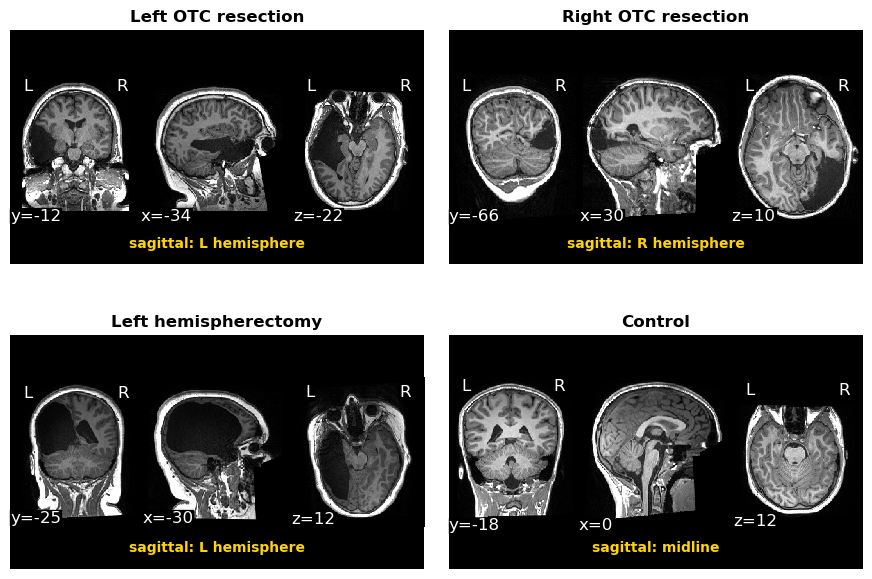

In [6]:
#!/usr/bin/env python
"""
Representative anatomy figure: one exemplar per surgery type + one control = 4 panels (2x2).
RUN ON THE CLUSTER. Cut coords are starting guesses — tune against each scan.
Heads equalized by tight head-bbox crop (world coords preserved). Sagittal (middle)
view labeled with its hemisphere (from cut x-sign).
"""
import os
import nibabel as nib
from matplotlib import gridspec
from nilearn import image, plotting

RAW_DIR = "/lab_data/behrmannlab/hemi/Raw"     # adjust if T1s live elsewhere
SES = "ses-01"
T1  = "{raw}/{sub}/{ses}/anat/{sub}_{ses}_T1w.nii.gz"
DIM = -1.25

# (row, col, sub, title two-line, (x,y,z) cut)
PANELS = [
    (0,0,"sub-044","Left OTC resection",   (-34,-12,-22)),
    (0,1,"sub-004","Right OTC resection",  ( 30,-66, 10)),
    (1,0,"sub-099","Left hemispherectomy", (-30,-25, 12)),
    (1,1,"sub-094","Control",              (  0,-18, 12)),
]

MARGIN = {"sub-044": 20}   # zero-background frame (voxels); larger = smaller head

def tight_crop(img, margin=6, frac=0.12):
    """Crop to head bbox, then add `margin` voxels of real zero-background on every
    side so the head occupies less of the FOV. World coords preserved."""
    d = img.get_fdata()
    thr = frac * np.percentile(d, 99.5)
    mask = d > thr
    if mask.sum() == 0: return img
    idx = np.array(np.where(mask))
    lo = idx.min(1); hi = idx.max(1) + 1
    sl = tuple(slice(int(a), int(b)) for a, b in zip(lo, hi))
    d = np.pad(d[sl], margin, mode="constant")
    aff = img.affine.copy()
    aff[:3, 3] = aff[:3, 3] + aff[:3, :3].dot(lo - margin)
    return nib.Nifti1Image(d, aff)

def show(ax, sub, title, cut):
    path = T1.format(raw=RAW_DIR, sub=sub, ses=SES)
    if not os.path.exists(path):
        ax.text(0.5,0.5,f"{title}\n(T1 not found)",ha="center",va="center",fontsize=9); ax.axis("off"); return
    anat = tight_crop(image.load_img(path), margin=MARGIN.get(sub, 6))
    plotting.plot_anat(anat, cut_coords=cut, draw_cross=False, dim=DIM, axes=ax, annotate=True)
    ax.set_title(title, fontsize=12, fontweight="bold")
    sag = "midline" if abs(cut[0]) < 5 else ("R hemisphere" if cut[0] > 0 else "L hemisphere")
    ax.text(0.5, 0.06, f"sagittal: {sag}", transform=ax.transAxes, ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="#FFD400")

fig = plt.figure(figsize=(11, 7))
gs = gridspec.GridSpec(2, 2, hspace=0.30, wspace=0.06)
for r, c, sub, title, cut in PANELS:
    show(fig.add_subplot(gs[r, c]), sub, title, cut)
plt.savefig(FIG_DIR / 'representative_anatomy.png', dpi=300, bbox_inches='tight')
plt.show()

## 4 · Peak coordinates (MNI)
Reads `peak_coords_mni.csv`. House parcel is `house_PPA_strict`, matching the rest of the figure set.

In [7]:
# ─── Peak-coordinate machinery ───────────────────────────────────────────
# peak_xy() reads an MNI peak from the coords table. Distinct from
# mds_coords() in §9, which embeds a similarity matrix — the two source
# notebooks both called their version `coords`.

pk_c, pk_p = load_harmonized(MNI_CSV, 'peak coords (MNI)', collapse_pairs=True)


def confidence_ellipse(x, y, ax, n_std=1.0, **kw):
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx = np.sqrt(1 + pearson); ry = np.sqrt(1 - pearson)
    e = Ellipse((0, 0), width=2 * rx, height=2 * ry, **kw)
    sx = np.sqrt(cov[0, 0]) * n_std; sy = np.sqrt(cov[1, 1]) * n_std
    t = (mtransforms.Affine2D().rotate_deg(45).scale(sx, sy)
         .translate(np.mean(x), np.mean(y)))
    e.set_transform(t + ax.transData); ax.add_patch(e)


def peak_xy(d, sub, roi, h):
    m = d[(d['subject_id'] == sub) & (d['category'] == roi) & (d['hemi'] == h)]
    if len(m) == 0:
        return None
    x, y = float(m['peak_x_mni'].iloc[0]), float(m['peak_y_mni'].iloc[0])
    return None if (np.isnan(x) or np.isnan(y)) else (x, y)


def intact_of(sub):
    m = pk_p[pk_p['subject_id'] == sub]
    return None if m.empty else ('l' if m['intact_hemi'].iloc[0] == 'left' else 'r')


ctrl_subs_mni = sorted(pk_c['subject_id'].unique())
pt_subs_mni   = sorted(pk_p['subject_id'].unique())
xlim, ylim = (-80, 80), (-100, 0)
midline = (pk_c[pk_c['hemi'] == 'l']['peak_x_mni'].mean()
           + pk_c[pk_c['hemi'] == 'r']['peak_x_mni'].mean()) / 2
print(f'midline estimate: {midline:.1f} mm')

peak coords (MNI): ctrl n=36  pt n=24  {'left': 12, 'right': 12}
midline estimate: 0.3 mm


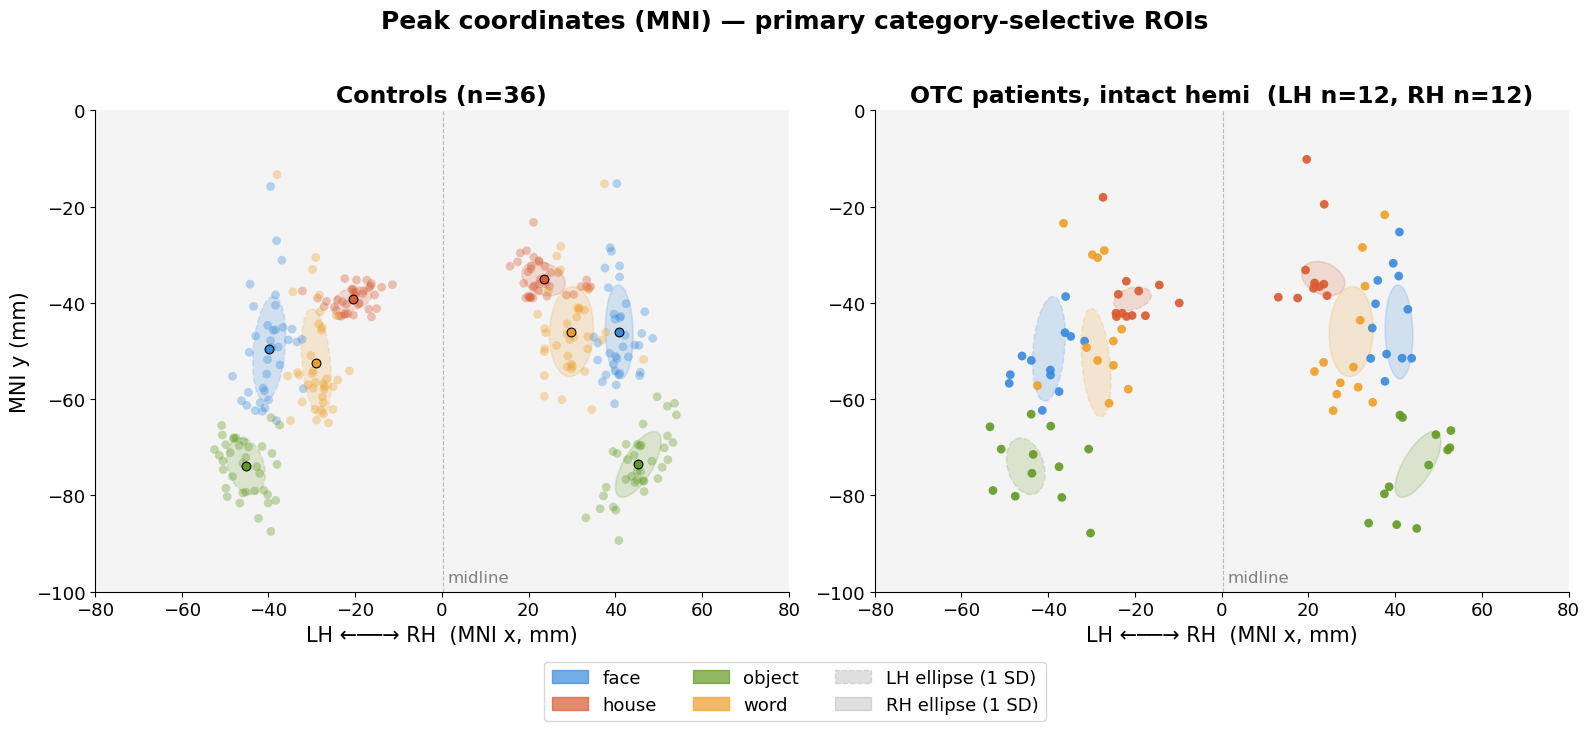

In [8]:
# ─── Peak coordinates plot — primary ROIs ────────────────────────────────
CATS_PRIMARY = [(CAT_PRIMARY[c], CAT_COLORS[c], c)
                for c in ('face', 'house', 'object', 'word')]
n_lh = sum(1 for s in pt_subs_mni if intact_of(s) == 'l')
n_rh = sum(1 for s in pt_subs_mni if intact_of(s) == 'r')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')
for ax_idx, (ax, is_ctrl) in enumerate([(axes[0], True), (axes[1], False)]):
    ax.set_facecolor('#f4f4f4')
    for roi, color, _ in CATS_PRIMARY:
        for hemi, ls in [('l', '--'), ('r', '-')]:
            pts = [peak_xy(pk_c, s, roi, hemi) for s in ctrl_subs_mni]
            pts = np.array([p for p in pts if p is not None])
            if len(pts) < 3:
                continue
            x, y = pts[:, 0], pts[:, 1]
            confidence_ellipse(x, y, ax, n_std=1.0, facecolor=color, alpha=0.18,
                               edgecolor=color, linewidth=1.2, linestyle=ls)
            if is_ctrl:
                ax.scatter(x, y, color=color, alpha=0.35, s=40, edgecolors='none', zorder=2)
                ax.scatter(x.mean(), y.mean(), color=color, s=40, edgecolors='black',
                           linewidth=0.8, marker='o', zorder=5)
        if not is_ctrl:
            for sub in pt_subs_mni:
                pt_h = intact_of(sub)
                if pt_h is None:
                    continue
                p = peak_xy(pk_p, sub, roi, pt_h)
                if p is None:
                    continue
                ax.scatter(p[0], p[1], color=color, s=40, edgecolors='none',
                           alpha=0.9, zorder=6)
    ax.axvline(midline, color='gray', lw=0.8, ls='--', alpha=0.5, zorder=1)
    ax.text(midline + 1, ylim[0] + 2, 'midline', fontsize=12, color='gray')
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel('LH ←──→ RH  (MNI x, mm)', fontsize=15)
    ax.tick_params(axis='both', labelsize=13)
    if ax_idx == 0:
        ax.set_ylabel('MNI y (mm)', fontsize=15)
        ax.set_title(f'Controls (n={len(ctrl_subs_mni)})', fontsize=17, fontweight='bold')
    else:
        ax.set_title(f'OTC patients, intact hemi  (LH n={n_lh}, RH n={n_rh})',
                     fontsize=17, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

leg = [Patch(facecolor=c, alpha=0.7, edgecolor=c, label=lab) for _, c, lab in CATS_PRIMARY]
leg += [Patch(facecolor='gray', alpha=0.25, edgecolor='gray', linestyle='--',
              label='LH ellipse (1 SD)'),
        Patch(facecolor='gray', alpha=0.25, edgecolor='gray', linestyle='-',
              label='RH ellipse (1 SD)')]
fig.legend(handles=leg, loc='lower center', ncol=3, fontsize=13, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Peak coordinates (MNI) — primary category-selective ROIs',
             fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(FIG_DIR / 'peak_scatter_mni_primary.png', dpi=300, bbox_inches='tight')
plt.show()

## 5 · Peak selectivity
`peak_z` — the single highest z inside each ROI's searchmask for that category's contrast, one value per subject × ROI × hemisphere. `plot_primary_panel` now accepts `q_map`; without it the call raised `TypeError`.

In [9]:
# ─── Shared panel builder (peak selectivity; any per-ROI scalar measure) ─
PLOT_KIND = 'box'          # 'box' or 'violin'
CTRL_A, PT_A = 0.9, 0.3    # control solid, patient translucent
CATS_PANEL = ['face', 'house', 'object', 'word']


def q_for(measure, cat, h):
    """q from STATS by (measure, level=primary ROI, hemi), patient vs control."""
    m = STATS[(STATS['measure'] == measure) &
              (STATS['comparison'] == 'patient_vs_control') &
              (STATS['level'] == CAT_PRIMARY[cat]) & (STATS['hemi'] == h)]
    return float(m['q_fdr'].iloc[0]) if len(m) else np.nan


def draw_dist(ax, vals, pos, col, alpha, width=0.5):
    if len(vals) < 2:
        return
    if PLOT_KIND == 'violin':
        parts = ax.violinplot([vals], positions=[pos], widths=width,
                              showmeans=False, showmedians=False, showextrema=False)
        for b in parts['bodies']:
            b.set_facecolor(col); b.set_alpha(alpha); b.set_edgecolor(col)
    else:
        bp = ax.boxplot([vals], positions=[pos], widths=width, patch_artist=True,
                        showfliers=False, manage_ticks=False, zorder=2)
        for box in bp['boxes']:
            box.set_facecolor(col); box.set_alpha(alpha); box.set_edgecolor(col)
        for el in ('whiskers', 'caps'):
            for ln in bp[el]:
                ln.set_color(col)
        for ln in bp['medians']:
            ln.set_color('black')


def build_primary_table(df, subjects, value_col, log10=False):
    rows = []
    for s in subjects:
        for cat in CAT_PRIMARY:
            for h in ('l', 'r'):
                m = df[(df['subject_id'] == s) & (df['category'] == CAT_PRIMARY[cat]) &
                       (df['hemi'] == h)].drop_duplicates(
                           subset=['subject_id', 'category', 'hemi'])
                v = m[value_col].dropna().values
                if log10:
                    v = v[v > 0]
                    val = np.mean(np.log10(v)) if len(v) else np.nan
                else:
                    val = np.mean(v) if len(v) else np.nan
                if not np.isnan(val):
                    rows.append({'subject_id': s, 'category': cat, 'hemi': h, 'val': val})
    return pd.DataFrame(rows)


def plot_primary_panel(measure, value_col, ylabel, fname, suptitle,
                       ctrl_df, pt_df, log10=False, y0=None,
                       legend_loc='upper left', q_map=None):
    """q_map, when given, is {(category, hemi): q} and overrides q_for().
    Needed for measures whose STATS `measure` name differs from `measure`
    here (peak_z -> peak_selectivity)."""
    def _q(cat, h):
        return q_map.get((cat, h), np.nan) if q_map is not None else q_for(measure, cat, h)

    ctrl_t = build_primary_table(ctrl_df, sorted(ctrl_df['subject_id'].unique()),
                                 value_col, log10)
    pt_t = build_primary_table(pt_df, sorted(pt_df['subject_id'].unique()),
                               value_col, log10)
    pt_t['intact_hemi'] = pt_t['subject_id'].map(
        dict(zip(pt_df['subject_id'], pt_df['intact_hemi'])))
    pt_t = pt_t[((pt_t['intact_hemi'] == 'left') & (pt_t['hemi'] == 'l')) |
                ((pt_t['intact_hemi'] == 'right') & (pt_t['hemi'] == 'r'))]

    INTRA, INTER, CAT_GAP = 0.55, 0.7, 1.0
    pos_w = [0.0, INTRA, INTRA + INTER, 2 * INTRA + INTER]
    cat_width = pos_w[-1]
    fig, ax = plt.subplots(figsize=(10, 5))
    rng = np.random.RandomState(42); cat_centers = []
    allv = np.concatenate([ctrl_t['val'].dropna().values, pt_t['val'].dropna().values])
    gmax, gmin = np.nanmax(allv), np.nanmin(allv)
    brack_h = (gmax - gmin) * 0.02
    for ci, cat in enumerate(CATS_PANEL):
        col = CAT_COLORS[cat]; base = ci * (cat_width + CAT_GAP)
        positions = [base + p for p in pos_w]
        cat_centers.append(np.mean(positions))
        cl = ctrl_t[(ctrl_t['category'] == cat) & (ctrl_t['hemi'] == 'l')]['val'].values
        cr = ctrl_t[(ctrl_t['category'] == cat) & (ctrl_t['hemi'] == 'r')]['val'].values
        pl = pt_t[(pt_t['category'] == cat) & (pt_t['hemi'] == 'l')]['val'].values
        pr = pt_t[(pt_t['category'] == cat) & (pt_t['hemi'] == 'r')]['val'].values
        for vals, p, a in [(cl, positions[0], CTRL_A), (pl, positions[1], PT_A),
                           (cr, positions[2], CTRL_A), (pr, positions[3], PT_A)]:
            vals = vals[~np.isnan(vals)]
            if len(vals) == 0:
                continue
            draw_dist(ax, vals, p, col, a)
            jit = rng.uniform(-0.09, 0.09, len(vals))
            ax.scatter(np.full(len(vals), p) + jit, vals, facecolors=col, alpha=0.7,
                       s=18, edgecolors='black', linewidths=0.4, zorder=3)
        for (h, x_l, x_r) in [('l', positions[0], positions[1]),
                              ('r', positions[2], positions[3])]:
            s = stars(_q(cat, h))
            if not s:
                continue
            by = gmax + brack_h * 2
            ax.plot([x_l, x_l, x_r, x_r], [by, by + brack_h, by + brack_h, by],
                    color='black', lw=1, zorder=6)
            ax.text((x_l + x_r) / 2, by + brack_h, s, ha='center', va='bottom',
                    color='red', fontsize=13, fontweight='bold', zorder=6)
    ax.set_xticks([])
    ax.set_ylabel(ylabel, fontsize=14); ax.tick_params(axis='y', labelsize=12)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for cat, center in zip(CATS_PANEL, cat_centers):
        ax.text(center, -0.04, cat.title(), fontsize=14, fontweight='bold',
                color=CAT_COLORS[cat], ha='center', va='top',
                transform=ax.get_xaxis_transform())
    tw = len(CATS_PANEL) * cat_width + (len(CATS_PANEL) - 1) * CAT_GAP
    ax.set_xlim(-0.35, tw + 0.35); ax.margins(x=0.005)
    yr = gmax - gmin
    ax.set_ylim(y0 if y0 is not None else gmin - 0.04 * yr, gmax + 0.14 * yr)
    ax.legend(handles=[Patch(facecolor='gray', alpha=CTRL_A, label='Control'),
                       Patch(facecolor='gray', alpha=PT_A, label='Patient (intact hemi)')],
              loc=legend_loc, fontsize=11, frameon=True, framealpha=0.9)
    plt.suptitle(suptitle, fontsize=13, fontweight='bold', y=0.99)
    plt.subplots_adjust(bottom=0.08, top=0.93, left=0.09, right=0.99)
    plt.savefig(FIG_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

peak_selectivity q cells: pt-vs-ctrl 8, ctrl asym 4, pt subgroup 4
panels: ['VWFA', 'FFA', 'PPA', 'LO']
  VWFA {'ctrl L': 36, 'ctrl R': 36, 'pt L': 12, 'pt R': 12}
  FFA {'ctrl L': 36, 'ctrl R': 36, 'pt L': 12, 'pt R': 12}
  PPA {'ctrl L': 36, 'ctrl R': 36, 'pt L': 12, 'pt R': 12}
  LO {'ctrl L': 36, 'ctrl R': 36, 'pt L': 12, 'pt R': 12}


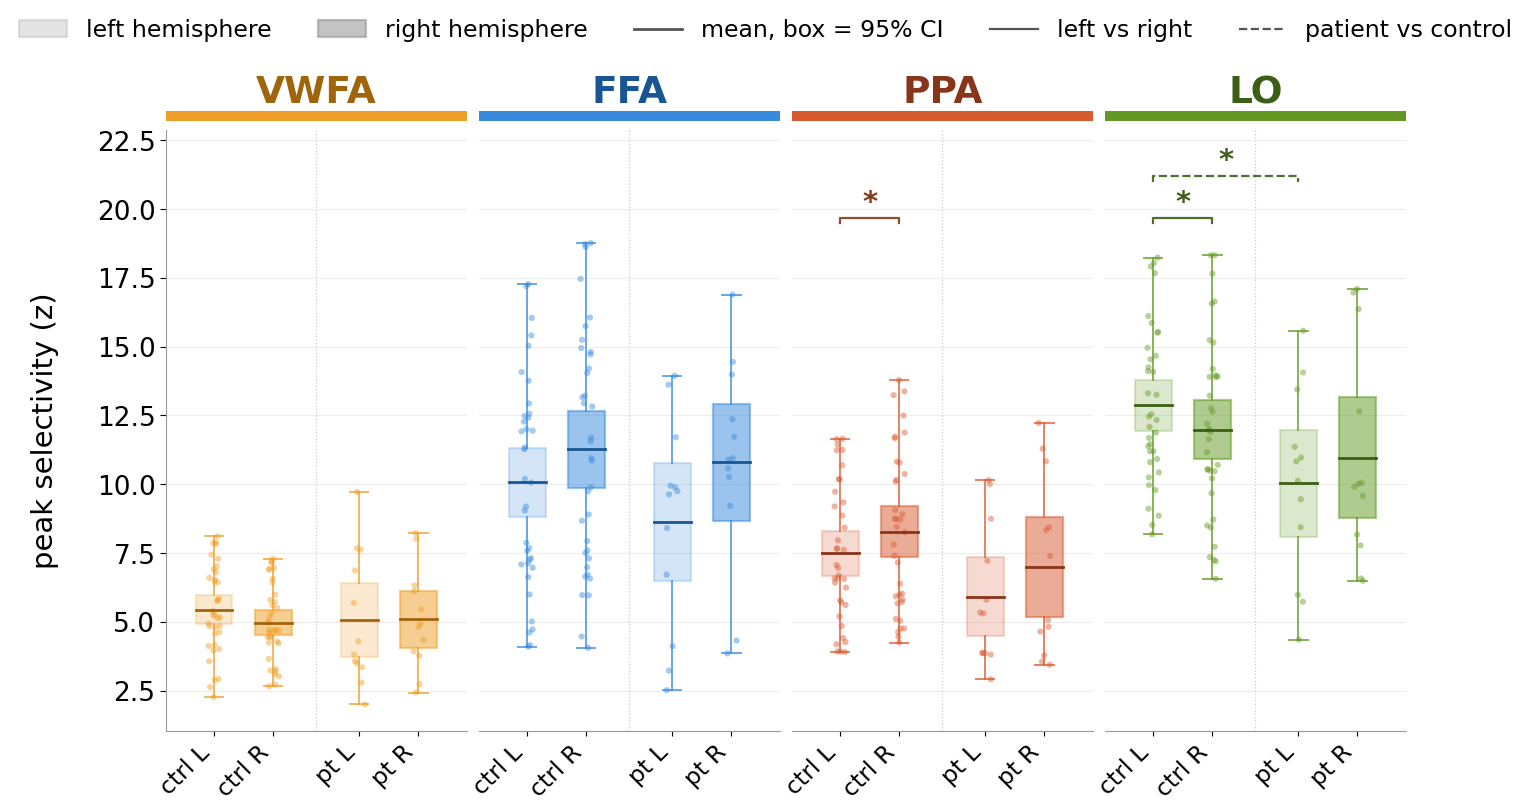

In [22]:
# ─── Peak selectivity ────────────────────────────────────────────────────
# Same grammar as §7: four slots per ROI (ctrl L, ctrl R, pt L, pt R),
# rectangle = mean ± 95% CI, whisker = min/max, points = subjects.
# Solid bracket  = left vs right within a group (control asymmetry, patient subgroup)
# Dashed bracket = patient vs matched-hemisphere control
_s = STATS[STATS['measure'] == 'peak_selectivity']
Q_PVC_PK  = {(r.level, r.hemi): r.q_fdr
             for r in _s[_s['comparison'] == 'patient_vs_control'].itertuples()}
Q_CASY_PK = {r.level: r.q_fdr
             for r in _s[_s['comparison'] == 'control_asymmetry'].itertuples()}
Q_PSUB_PK = {r.level: r.q_fdr
             for r in _s[_s['comparison'] == 'patient_subgroup'].itertuples()}
print(f'peak_selectivity q cells: pt-vs-ctrl {len(Q_PVC_PK)}, '
      f'ctrl asym {len(Q_CASY_PK)}, pt subgroup {len(Q_PSUB_PK)}')

PK_COL = 'peak_z'


def _pvals(roi, slot, hemi):
    if slot.startswith('ctrl'):
        d = peak_c[(peak_c['category'] == roi) & (peak_c['hemi'] == hemi)]
    else:
        intact = 'left' if hemi == 'l' else 'right'
        d = peak_p[(peak_p['category'] == roi) & (peak_p['intact_hemi'] == intact)]
    return d[PK_COL].dropna().values


ROIS_PK = [r for r in ROI_ORDER if r in set(peak_c['category'])]
print('panels:', [ROI_TITLE.get(r, r) for r in ROIS_PK])
for r in ROIS_PK:
    print(' ', ROI_TITLE[r], {s[0]: len(_pvals(r, s[0], s[2])) for s in SLOTS})

# Bracket offsets scale with the shared y-range, unlike §7's fixed 0.20/0.46,
# because peak z spans roughly 2-18 rather than -0.5-1.5.
_allv = np.concatenate([_pvals(r, s[0], s[2]) for r in ROIS_PK for s in SLOTS])
_span = _allv.max() - _allv.min()
GAP1, GAP2 = 0.055 * _span, 0.145 * _span
_gtop = _allv.max()

BOX_W, JIT = 0.34, 0.055
_rng = np.random.RandomState(0)

fig, axes = plt.subplots(1, len(ROIS_PK), figsize=(4.0 * len(ROIS_PK), 7.8),
                         sharey=True, gridspec_kw={'wspace': 0.04})
axes = np.atleast_1d(axes)
fig.patch.set_facecolor('white')

for i, (ax, roi) in enumerate(zip(axes, ROIS_PK)):
    base = CAT_COLORS[ROI_CAT[roi]]
    dark = shade(base, 0.62)
    ax.set_facecolor('white')
    ax.yaxis.grid(True, color='#ededed', lw=0.8)
    ax.set_axisbelow(True)
    ax.axvline(0.95, color='#ccc', lw=0.9, ls=':')

    means = {}
    for slot, xpos, hemi, alpha in SLOTS:
        v = _pvals(roi, slot, hemi)
        if len(v) < 3:
            continue
        m = v.mean()
        hw = 1.96 * v.std(ddof=1) / np.sqrt(len(v))
        means[slot] = xpos
        for y0, y1 in ((v.min(), m - hw), (m + hw, v.max())):
            if y1 > y0:
                ax.plot([xpos, xpos], [y0, y1], color=base, lw=1.4, alpha=0.75, zorder=1)
        for _y in (v.min(), v.max()):
            ax.plot([xpos - BOX_W / 4, xpos + BOX_W / 4], [_y, _y],
                    color=base, lw=1.4, alpha=0.75, zorder=1)
        ax.add_patch(plt.Rectangle((xpos - BOX_W / 2, m - hw), BOX_W, 2 * hw,
                                   facecolor=base, alpha=alpha,
                                   edgecolor=base, lw=1.6, zorder=2))
        ax.plot([xpos - BOX_W / 2, xpos + BOX_W / 2], [m, m], color=dark, lw=2.0, zorder=4)
        ax.scatter(xpos + _rng.uniform(-JIT, JIT, len(v)), v, s=20,
                   facecolors=base, alpha=0.45, edgecolors='none', zorder=3)

    # solid: left vs right within a group
    for pair, qv in ((('ctrl L', 'ctrl R'), Q_CASY_PK.get(roi)),
                     (('pt L', 'pt R'), Q_PSUB_PK.get(roi))):
        s = stars(qv)
        if not s or pair[0] not in means or pair[1] not in means:
            continue
        x0, x1 = means[pair[0]], means[pair[1]]
        yb = _gtop + GAP1
        ax.plot([x0, x0, x1, x1], [yb - 0.012 * _span, yb, yb, yb - 0.012 * _span],
                color=dark, lw=1.6, alpha=0.9, zorder=5, clip_on=False)
        ax.text((x0 + x1) / 2, yb + 0.004 * _span, s, ha='center', va='bottom',
                fontsize=21, color=dark, fontweight='bold', clip_on=False)

    # dashed: patient vs matched-hemisphere control
    for hemi, cslot, pslot in (('l', 'ctrl L', 'pt L'), ('r', 'ctrl R', 'pt R')):
        s = stars(Q_PVC_PK.get((roi, hemi)))
        if not s or cslot not in means or pslot not in means:
            continue
        x0, x1 = means[cslot], means[pslot]
        yb = _gtop + GAP2
        ax.plot([x0, x0, x1, x1], [yb - 0.012 * _span, yb, yb, yb - 0.012 * _span],
                color=dark, lw=1.6, ls='--', alpha=0.9, zorder=5, clip_on=False)
        ax.text((x0 + x1) / 2, yb + 0.004 * _span, s, ha='center', va='bottom',
                fontsize=21, color=dark, fontweight='bold', clip_on=False)

    ax.set_xticks([s[1] for s in SLOTS])
    ax.set_xticklabels([s[0] for s in SLOTS], rotation=45, ha='right', fontsize=17)
    ax.tick_params(axis='y', labelsize=19, length=4)
    ax.set_title(ROI_TITLE.get(roi, roi), fontsize=27, fontweight='bold', color=dark, pad=20)
    ax.add_patch(plt.Rectangle((0.0, 1.015), 1.0, 0.017, color=base,
                               transform=ax.transAxes, clip_on=False, lw=0))
    ax.set_xlim(-0.45, 2.35)
    ax.spines['left'].set_color('#999')
    ax.spines['bottom'].set_color('#999')
    if i > 0:
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='y', length=0)

axes[0].set_ylim(top=_gtop + GAP2 + 0.10 * _span)
axes[0].set_ylabel('peak selectivity (z)\n', fontsize=21)

handles = [Patch(facecolor='#888', alpha=0.22, edgecolor='#888', lw=1.6,
                 label='left hemisphere'),
           Patch(facecolor='#888', alpha=0.50, edgecolor='#888', lw=1.6,
                 label='right hemisphere'),
           Line2D([], [], color='#555', lw=2.0, label='mean, box = 95% CI'),
           Line2D([], [], color='#555', lw=1.6, label='left vs right'),
           Line2D([], [], color='#555', lw=1.6, ls='--', label='patient vs control')]
fig.legend(handles=handles, loc='upper center', frameon=False, ncol=5,
           bbox_to_anchor=(0.5, 1.05), fontsize=17)

fig.savefig(FIG_DIR / 'peak_selectivity.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()

## 6 · Number of category-selective voxels
One panel per ROI, x grouped by group: controls (L, R) then patients (L, R). Rectangle = mean ± 95% CI, whiskers = full range broken at the box, line = mean, fill transparency = hemisphere. Brackets only where corrected: solid = left vs right within a group, dashed = patient vs matched-hemisphere control. `volume` is sqrt-transformed before ComBat and left on that scale, so boxes and stars are in sqrt(count) units. VWFA, FFA and PPA share one y scale; LO carries its own.

selective_voxels q cells: pt-vs-ctrl 8, ctrl asym 4, pt subgroup 4
panels: ['VWFA', 'FFA', 'PPA', 'LO']
  VWFA {'ctrl L': 36, 'ctrl R': 36, 'pt L': 12, 'pt R': 12}
  FFA {'ctrl L': 36, 'ctrl R': 36, 'pt L': 12, 'pt R': 12}
  PPA {'ctrl L': 36, 'ctrl R': 36, 'pt L': 12, 'pt R': 12}
  LO {'ctrl L': 36, 'ctrl R': 36, 'pt L': 12, 'pt R': 12}


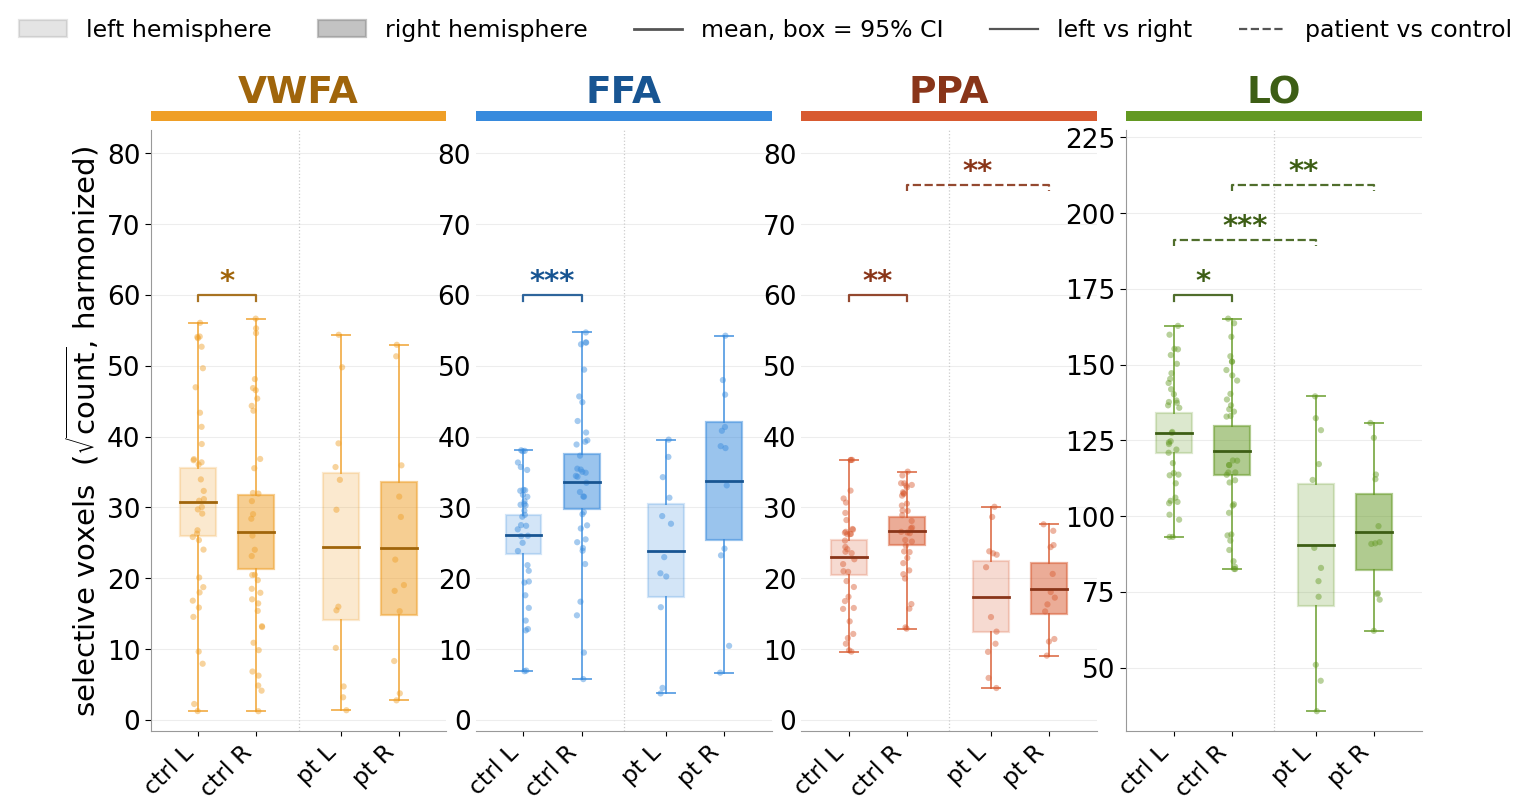

In [11]:
# ─── Selective voxels ────────────────────────────────────────────────────
VOX_COL   = 'volume'
OWN_SCALE = {'object_LOC'}          # panels excluded from the shared y group

_v = STATS[STATS['measure'] == 'selective_voxels']
QV_PVC  = {(r.level, r.hemi): r.q_fdr
           for r in _v[_v['comparison'] == 'patient_vs_control'].itertuples()}
QV_CASY = {r.level: r.q_fdr
           for r in _v[_v['comparison'] == 'control_asymmetry'].itertuples()}
QV_PSUB = {r.level: r.q_fdr
           for r in _v[_v['comparison'] == 'patient_subgroup'].itertuples()}
print(f'selective_voxels q cells: pt-vs-ctrl {len(QV_PVC)}, '
      f'ctrl asym {len(QV_CASY)}, pt subgroup {len(QV_PSUB)}')


def _vvals(roi, slot, hemi):
    if slot.startswith('ctrl'):
        d = vox_c[(vox_c['category'] == roi) & (vox_c['hemi'] == hemi)]
    else:
        intact = 'left' if hemi == 'l' else 'right'
        d = vox_p[(vox_p['category'] == roi) & (vox_p['intact_hemi'] == intact)]
    return d[VOX_COL].dropna().values


ROIS_VOX = [r for r in ROI_ORDER if r in set(vox_c['category'])]
print('panels:', [ROI_TITLE.get(r, r) for r in ROIS_VOX])
for r in ROIS_VOX:
    print(' ', ROI_TITLE[r], {s[0]: len(_vvals(r, s[0], s[2])) for s in SLOTS})


def _range(rois):
    pool = np.concatenate([_vvals(r, s[0], s[2]) for r in rois for s in SLOTS
                           if len(_vvals(r, s[0], s[2])) >= 3])
    lo, hi = float(pool.min()), float(pool.max())
    return lo, hi, (hi - lo) or 1.0


_shared = [r for r in ROIS_VOX if r not in OWN_SCALE]
LIMS = {}
if _shared:
    lo, hi, sp = _range(_shared)
    for r in _shared:
        LIMS[r] = (lo, hi, sp)
for r in ROIS_VOX:
    if r in OWN_SCALE:
        LIMS[r] = _range([r])

BOX_W, JIT = 0.34, 0.055
_rng = np.random.RandomState(0)

fig, axes = plt.subplots(1, len(ROIS_VOX), figsize=(4.1 * len(ROIS_VOX), 7.8),
                         sharey=False, gridspec_kw={'wspace': 0.10})
axes = np.atleast_1d(axes)
fig.patch.set_facecolor('white')

for i, (ax, roi) in enumerate(zip(axes, ROIS_VOX)):
    base = CAT_COLORS[ROI_CAT[roi]]
    dark = shade(base, 0.62)
    gmin, gmax, span = LIMS[roi]
    ax.set_facecolor('white')
    ax.yaxis.grid(True, color='#ededed', lw=0.8)
    ax.set_axisbelow(True)
    ax.axvline(0.95, color='#ccc', lw=0.9, ls=':')

    means = {}
    for slot, xpos, hemi, alpha in SLOTS:
        v = _vvals(roi, slot, hemi)
        if len(v) < 3:
            continue
        m = v.mean()
        hw = 1.96 * v.std(ddof=1) / np.sqrt(len(v))
        means[slot] = xpos
        for y0, y1 in ((v.min(), m - hw), (m + hw, v.max())):
            if y1 > y0:
                ax.plot([xpos, xpos], [y0, y1], color=base, lw=1.4, alpha=0.75, zorder=1)
        for _y in (v.min(), v.max()):
            ax.plot([xpos - BOX_W / 4, xpos + BOX_W / 4], [_y, _y],
                    color=base, lw=1.4, alpha=0.75, zorder=1)
        ax.add_patch(plt.Rectangle((xpos - BOX_W / 2, m - hw), BOX_W, 2 * hw,
                                   facecolor=base, alpha=alpha,
                                   edgecolor=base, lw=1.6, zorder=2))
        ax.plot([xpos - BOX_W / 2, xpos + BOX_W / 2], [m, m], color=dark, lw=2.0, zorder=4)
        ax.scatter(xpos + _rng.uniform(-JIT, JIT, len(v)), v, s=20,
                   facecolors=base, alpha=0.45, edgecolors='none', zorder=3)

    for pair, qv in ((('ctrl L', 'ctrl R'), QV_CASY.get(roi)),
                     (('pt L', 'pt R'), QV_PSUB.get(roi))):
        s = stars(qv)
        if not s or pair[0] not in means or pair[1] not in means:
            continue
        x0, x1 = means[pair[0]], means[pair[1]]
        yb = gmax + 0.06 * span
        ax.plot([x0, x0, x1, x1], [yb - 0.015 * span, yb, yb, yb - 0.015 * span],
                color=dark, lw=1.6, alpha=0.9, zorder=5)
        ax.text((x0 + x1) / 2, yb, s, ha='center', va='bottom',
                fontsize=21, color=dark, fontweight='bold')

    for hemi, cslot, pslot, lvl in (('l', 'ctrl L', 'pt L', 0.20),
                                    ('r', 'ctrl R', 'pt R', 0.34)):
        s = stars(QV_PVC.get((roi, hemi)))
        if not s or cslot not in means or pslot not in means:
            continue
        x0, x1 = means[cslot], means[pslot]
        yb = gmax + lvl * span
        ax.plot([x0, x0, x1, x1], [yb - 0.015 * span, yb, yb, yb - 0.015 * span],
                color=dark, lw=1.6, ls='--', alpha=0.9, zorder=5)
        ax.text((x0 + x1) / 2, yb, s, ha='center', va='bottom',
                fontsize=21, color=dark, fontweight='bold')

    ax.set_ylim(gmin - 0.05 * span, gmax + 0.48 * span)
    ax.set_xticks([s[1] for s in SLOTS])
    ax.set_xticklabels([s[0] for s in SLOTS], rotation=45, ha='right', fontsize=17)
    ax.tick_params(axis='y', labelsize=19, length=4)
    ax.set_title(ROI_TITLE.get(roi, roi), fontsize=27, fontweight='bold', color=dark, pad=20)
    ax.add_patch(plt.Rectangle((0.0, 1.015), 1.0, 0.017, color=base,
                               transform=ax.transAxes, clip_on=False, lw=0))
    ax.set_xlim(-0.45, 2.35)
    ax.spines['left'].set_color('#999')
    ax.spines['bottom'].set_color('#999')
    # hide the repeated axis only within the shared-scale group
    if i > 0 and roi not in OWN_SCALE and ROIS_VOX[i - 1] not in OWN_SCALE:
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='y', length=0)

axes[0].set_ylabel('selective voxels  ($\\sqrt{\\mathrm{count}}$, harmonized)', fontsize=21)

handles = [Patch(facecolor='#888', alpha=0.22, edgecolor='#888', lw=1.6,
                 label='left hemisphere'),
           Patch(facecolor='#888', alpha=0.50, edgecolor='#888', lw=1.6,
                 label='right hemisphere'),
           Line2D([], [], color='#555', lw=2.0, label='mean, box = 95% CI'),
           Line2D([], [], color='#555', lw=1.6, label='left vs right'),
           Line2D([], [], color='#555', lw=1.6, ls='--', label='patient vs control')]
fig.legend(handles=handles, loc='upper center', frameon=False, ncol=5,
           bbox_to_anchor=(0.5, 1.05), fontsize=17)

fig.savefig(FIG_DIR / 'selective_voxels.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 7 · Preferred-category similarity
Same layout and grammar as §6. Raw Fisher-z: higher = more similar = less differentiated.

distinctiveness q cells: pt-vs-ctrl 8, ctrl asym 4, pt subgroup 4
panels: ['VWFA', 'FFA', 'PPA', 'LO']
  VWFA {'ctrl L': 36, 'ctrl R': 36, 'pt L': 12, 'pt R': 12}
  FFA {'ctrl L': 36, 'ctrl R': 36, 'pt L': 12, 'pt R': 12}
  PPA {'ctrl L': 36, 'ctrl R': 36, 'pt L': 12, 'pt R': 12}
  LO {'ctrl L': 36, 'ctrl R': 36, 'pt L': 12, 'pt R': 12}


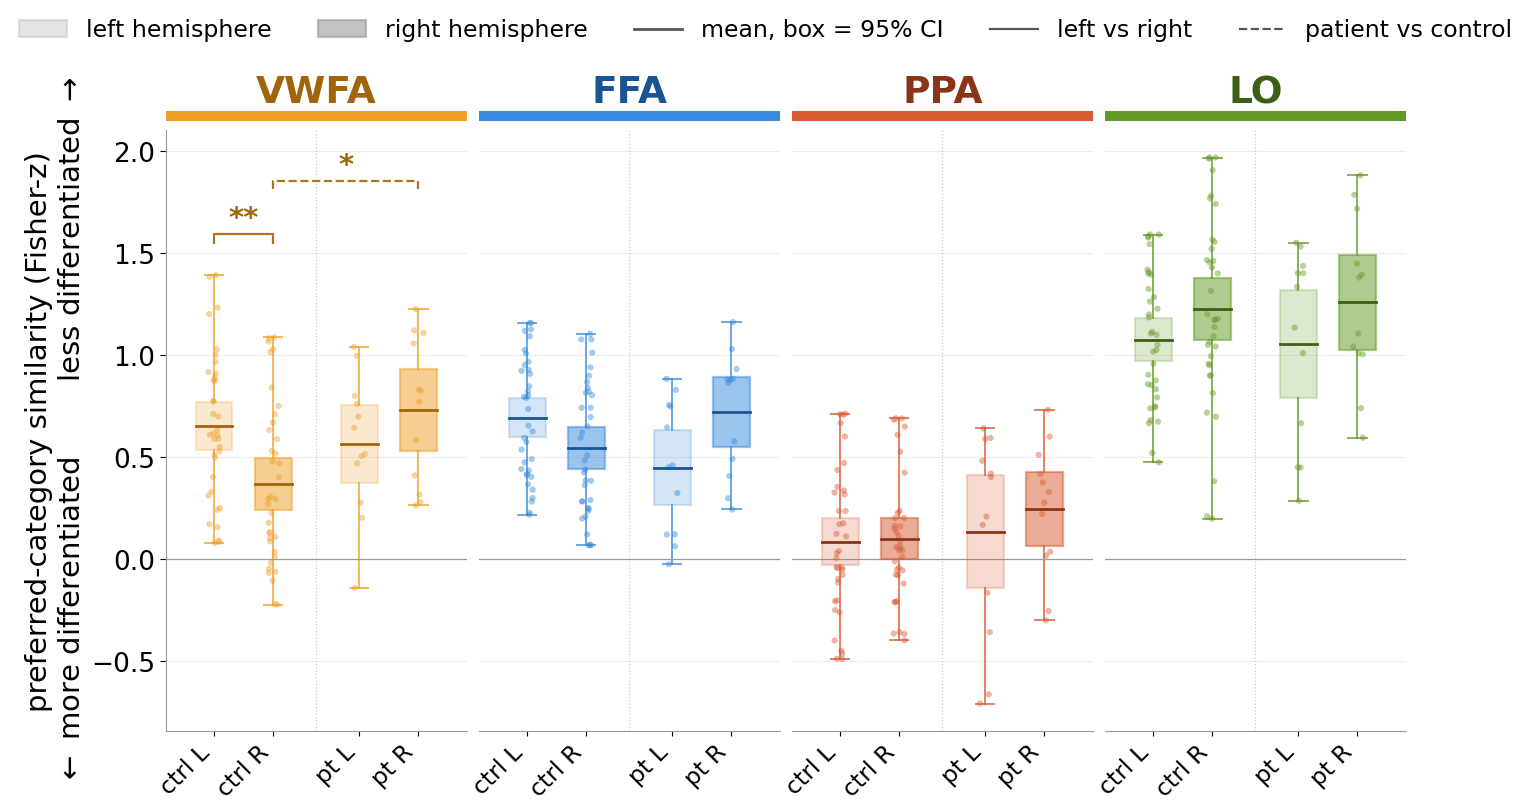

In [12]:
# ─── Preferred-category similarity ───────────────────────────────────────
_d = STATS[STATS['measure'] == 'distinctiveness']
Q_PVC  = {(r.level, r.hemi): r.q_fdr
          for r in _d[_d['comparison'] == 'patient_vs_control'].itertuples()}
Q_CASY = {r.level: r.q_fdr
          for r in _d[_d['comparison'] == 'control_asymmetry'].itertuples()}
Q_PSUB = {r.level: r.q_fdr
          for r in _d[_d['comparison'] == 'patient_subgroup'].itertuples()}
print(f'distinctiveness q cells: pt-vs-ctrl {len(Q_PVC)}, '
      f'ctrl asym {len(Q_CASY)}, pt subgroup {len(Q_PSUB)}')


def _dvals(roi, slot, hemi):
    if slot.startswith('ctrl'):
        d = rsa_c[(rsa_c['category'] == roi) & (rsa_c['hemi'] == hemi)]
    else:
        intact = 'left' if hemi == 'l' else 'right'
        d = rsa_p[(rsa_p['category'] == roi) & (rsa_p['intact_hemi'] == intact)]
    return d['liu_distinctiveness'].dropna().values


ROIS_DIST = [r for r in ROI_ORDER if r in set(rsa_c['category'])]
print('panels:', [ROI_TITLE.get(r, r) for r in ROIS_DIST])
for r in ROIS_DIST:
    print(' ', ROI_TITLE[r], {s[0]: len(_dvals(r, s[0], s[2])) for s in SLOTS})

BOX_W, JIT = 0.34, 0.055
_rng = np.random.RandomState(0)

fig, axes = plt.subplots(1, len(ROIS_DIST), figsize=(4.0 * len(ROIS_DIST), 7.8),
                         sharey=True, gridspec_kw={'wspace': 0.04})
axes = np.atleast_1d(axes)
fig.patch.set_facecolor('white')

for i, (ax, roi) in enumerate(zip(axes, ROIS_DIST)):
    base = CAT_COLORS[ROI_CAT[roi]]
    dark = shade(base, 0.62)
    ax.set_facecolor('white')
    ax.yaxis.grid(True, color='#ededed', lw=0.8)
    ax.set_axisbelow(True)
    ax.axhline(0, color='#999', lw=0.9)
    ax.axvline(0.95, color='#ccc', lw=0.9, ls=':')

    means, tops = {}, []
    for slot, xpos, hemi, alpha in SLOTS:
        v = _dvals(roi, slot, hemi)
        if len(v) < 3:
            continue
        m = v.mean()
        hw = 1.96 * v.std(ddof=1) / np.sqrt(len(v))
        means[slot] = xpos
        tops.append(v.max())
        for y0, y1 in ((v.min(), m - hw), (m + hw, v.max())):
            if y1 > y0:
                ax.plot([xpos, xpos], [y0, y1], color=base, lw=1.4, alpha=0.75, zorder=1)
        for _y in (v.min(), v.max()):
            ax.plot([xpos - BOX_W / 4, xpos + BOX_W / 4], [_y, _y],
                    color=base, lw=1.4, alpha=0.75, zorder=1)
        ax.add_patch(plt.Rectangle((xpos - BOX_W / 2, m - hw), BOX_W, 2 * hw,
                                   facecolor=base, alpha=alpha,
                                   edgecolor=base, lw=1.6, zorder=2))
        ax.plot([xpos - BOX_W / 2, xpos + BOX_W / 2], [m, m], color=dark, lw=2.0, zorder=4)
        ax.scatter(xpos + _rng.uniform(-JIT, JIT, len(v)), v, s=20,
                   facecolors=base, alpha=0.45, edgecolors='none', zorder=3)

    ytop = max(tops) if tops else 0

    # solid: left vs right within a group
    for pair, qv in ((('ctrl L', 'ctrl R'), Q_CASY.get(roi)),
                     (('pt L', 'pt R'), Q_PSUB.get(roi))):
        s = stars(qv)
        if not s or pair[0] not in means or pair[1] not in means:
            continue
        x0, x1 = means[pair[0]], means[pair[1]]
        yb = ytop + 0.20
        ax.plot([x0, x0, x1, x1], [yb - 0.04, yb, yb, yb - 0.04],
                color=dark, lw=1.6, alpha=0.9, zorder=5)
        ax.text((x0 + x1) / 2, yb + 0.01, s, ha='center', va='bottom',
                fontsize=21, color=dark, fontweight='bold')

    # dashed: patient vs matched-hemisphere control
    for hemi, cslot, pslot in (('l', 'ctrl L', 'pt L'), ('r', 'ctrl R', 'pt R')):
        s = stars(Q_PVC.get((roi, hemi)))
        if not s or cslot not in means or pslot not in means:
            continue
        x0, x1 = means[cslot], means[pslot]
        yb = ytop + 0.46
        ax.plot([x0, x0, x1, x1], [yb - 0.04, yb, yb, yb - 0.04],
                color=dark, lw=1.6, ls='--', alpha=0.9, zorder=5)
        ax.text((x0 + x1) / 2, yb + 0.01, s, ha='center', va='bottom',
                fontsize=21, color=dark, fontweight='bold')

    ax.set_xticks([s[1] for s in SLOTS])
    ax.set_xticklabels([s[0] for s in SLOTS], rotation=45, ha='right', fontsize=17)
    ax.tick_params(axis='y', labelsize=19, length=4)
    ax.set_title(ROI_TITLE.get(roi, roi), fontsize=27, fontweight='bold', color=dark, pad=20)
    ax.add_patch(plt.Rectangle((0.0, 1.015), 1.0, 0.017, color=base,
                               transform=ax.transAxes, clip_on=False, lw=0))
    ax.set_xlim(-0.45, 2.35)
    ax.spines['left'].set_color('#999')
    ax.spines['bottom'].set_color('#999')
    if i > 0:
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='y', length=0)

axes[0].set_ylabel('preferred-category similarity (Fisher-z)\n'
                   '$\\leftarrow$ more differentiated'
                   '        less differentiated $\\rightarrow$', fontsize=21)

handles = [Patch(facecolor='#888', alpha=0.22, edgecolor='#888', lw=1.6,
                 label='left hemisphere'),
           Patch(facecolor='#888', alpha=0.50, edgecolor='#888', lw=1.6,
                 label='right hemisphere'),
           Line2D([], [], color='#555', lw=2.0, label='mean, box = 95% CI'),
           Line2D([], [], color='#555', lw=1.6, label='left vs right'),
           Line2D([], [], color='#555', lw=1.6, ls='--', label='patient vs control')]
fig.legend(handles=handles, loc='upper center', frameon=False, ncol=5,
           bbox_to_anchor=(0.5, 1.05), fontsize=17)

fig.savefig(FIG_DIR / 'preferred_category_similarity.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()

## 8 · Between-category representational similarity
Three rows × four ROIs. Rows: LH-intact vs matched controls, RH-intact vs matched controls, LH-intact vs RH-intact patients. Word-containing pairs left of the dotted line.

`USE_STATS_Q = True` reads per-pair q from `stats_results_harmonized_corrected.csv`. The four values hardcoded in the source cell are kept below only for the printed comparison — set the flag to `False` to plot from them instead.

geometry q cells from STATS_CSV: 48 | q < .05: 5

STATS_CSV vs the hardcoded v3-draft values:
  row       roi               pair              STATS    draft   stars
  LH-intact face_FFA          face-word        0.0234   0.0234     * / *
  RH-intact face_FFA          face-word        0.0006   0.0006   *** / ***
  RH-intact word_VWFA         house-word       0.0054   0.0054    ** / **
  RH-intact word_VWFA         object-word      0.0327   0.0327     * / *


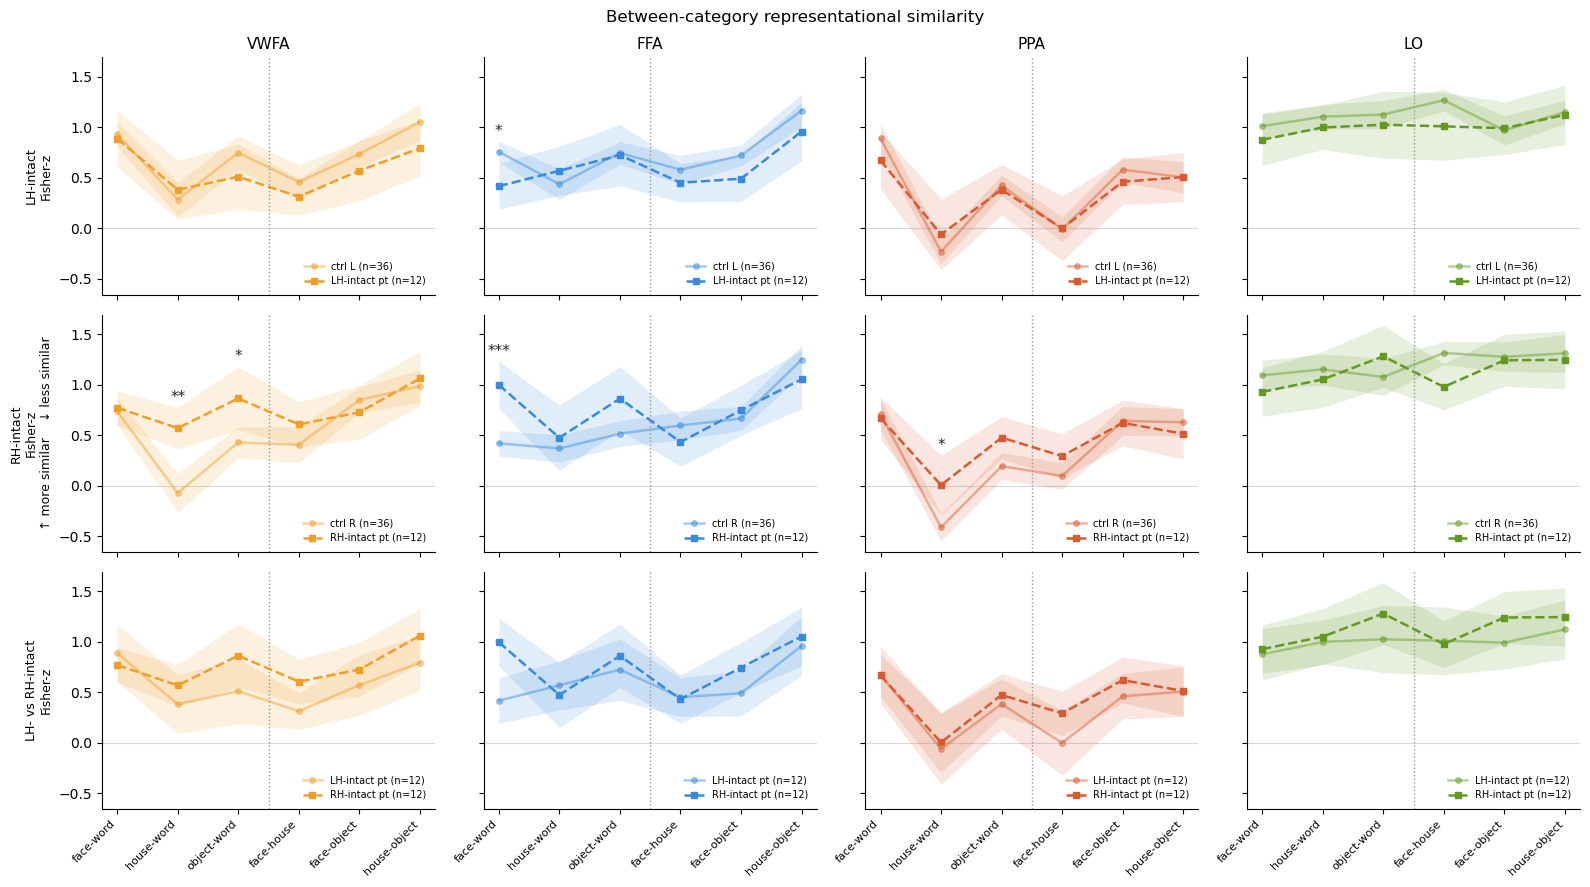

In [13]:
# ─── Between-category profiles ───────────────────────────────────────────
USE_STATS_Q = True
A_CTRL, A_PT = 0.45, 1.0        # line alpha only; patients darker

# Superseded: values as reported in the v3 draft, retained for comparison only.
QVALS_V3_DRAFT = {
    ('LH-intact', 'face_FFA',  'face-word'):   .0234,
    ('RH-intact', 'face_FFA',  'face-word'):   .0006,
    ('RH-intact', 'word_VWFA', 'house-word'):  .0054,
    ('RH-intact', 'word_VWFA', 'object-word'): .0327,
}

_g = STATS[(STATS['measure'] == 'geometry') &
           (STATS['comparison'] == 'patient_vs_control')]
Q_GEO = {}
for r in _g.itertuples():
    m = str(r.model)
    h = 'LH-intact' if 'LH-intact' in m else 'RH-intact' if 'RH-intact' in m else None
    roi = (m.replace('_LH-intact_pt_vs_ctrl', '')
            .replace('_RH-intact_pt_vs_ctrl', ''))
    if h is not None:
        Q_GEO[(h, roi, r.level)] = r.q_fdr
print(f'geometry q cells from STATS_CSV: {len(Q_GEO)}'
      f' | q < .05: {sum(1 for v in Q_GEO.values() if pd.notna(v) and v < .05)}')
print('\nSTATS_CSV vs the hardcoded v3-draft values:')
print(f'  {"row":<10}{"roi":<18}{"pair":<14}{"STATS":>9}{"draft":>9}   stars')
for k, dq in QVALS_V3_DRAFT.items():
    sq = Q_GEO.get(k)
    print(f'  {k[0]:<10}{k[1]:<18}{k[2]:<14}'
          f'{("n/a" if sq is None or pd.isna(sq) else f"{sq:.4f}"):>9}{dq:>9.4f}'
          f'   {stars(sq) or "-":>3} / {stars(dq)}')

QSRC = Q_GEO if USE_STATS_Q else {(k[0], k[1], k[2]): v
                                  for k, v in QVALS_V3_DRAFT.items()}


def _prof(d, roi):
    w = (d[d['category'] == roi]
         .pivot_table(index='subject_id', columns='pair', values='fisher_r')
         .reindex(columns=PAIRS_ORDERED))
    m = w.mean().values
    se = w.std(ddof=1) / np.sqrt(w.notna().sum()) * 1.96
    return m, se, len(w)


x = np.arange(len(PAIRS_ORDERED))
ROWS = [('LH-intact', 'l', 'left'), ('RH-intact', 'r', 'right'),
        ('LH- vs RH-intact', None, None)]

fig, axes = plt.subplots(3, len(ROI_ORDER), figsize=(16, 9), sharex=True, sharey='all')
fig.patch.set_facecolor('white')

for j, roi in enumerate(ROI_ORDER):
    color = CAT_COLORS[ROI_CAT[roi]]
    for i, (row_lab, hemi, intact) in enumerate(ROWS):
        ax = axes[i, j]
        if hemi is not None:
            series = [(_prof(rsa_c_long[rsa_c_long['hemi'] == hemi], roi),
                       f'ctrl {hemi.upper()}', A_CTRL, '-', 'o'),
                      (_prof(rsa_p_long[rsa_p_long['intact_hemi'] == intact], roi),
                       f'{row_lab} pt', A_PT, '--', 's')]
        else:
            series = [(_prof(rsa_p_long[rsa_p_long['intact_hemi'] == 'left'], roi),
                       'LH-intact pt', A_CTRL, '-', 'o'),
                      (_prof(rsa_p_long[rsa_p_long['intact_hemi'] == 'right'], roi),
                       'RH-intact pt', A_PT, '--', 's')]
        for (m, se, n), lab, a, ls, mk in series:
            ax.plot(x, m, ls, marker=mk, color=color, alpha=a, ms=4, lw=1.8,
                    label=f'{lab} (n={n})')
            ax.fill_between(x, m - se, m + se, color=color, alpha=0.15, lw=0)
        ax.axhline(0, color='0.85', lw=0.8, zorder=0)
        ax.axvline(2.5, ls=':', color='0.6', lw=1)
        for k, pr in enumerate(PAIRS_ORDERED):
            st = stars(QSRC.get((row_lab, roi, pr)))
            if st:
                hi = max(series[0][0][0][k] + series[0][0][1][k],
                         series[1][0][0][k] + series[1][0][1][k])
                ax.annotate(st, (k, hi), textcoords='offset points', xytext=(0, 4),
                            ha='center', fontsize=11, color='0.15')
        ax.legend(fontsize=7, frameon=False, loc='lower right')
        ax.spines[['top', 'right']].set_visible(False)
        if i == 0:
            ax.set_title(ROI_TITLE[roi], fontsize=11)
        if j == 0:
            if i == 1:
                ax.set_ylabel(f'{row_lab}\nFisher-z\n'
                              '↑ more similar    ↓ less similar', fontsize=9)
            else:
                ax.set_ylabel(f'{row_lab}\nFisher-z', fontsize=9)
        if i == 2:
            ax.set_xticks(x)
            ax.set_xticklabels(PAIRS_ORDERED, rotation=45, ha='right', fontsize=8)

fig.suptitle('Between-category representational similarity', fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / 'between_category_profiles.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()

## 9 · Procrustes / MDS configuration
Reads `fisher_r` from `rsa_v1_harmonized.csv`, the same harmonized source as §7 and §8 — it reuses the `rsa_*_long` frames already loaded in §1 rather than re-reading anything.

`peak_coords_mni.csv` is still the source for §4, because ComBat harmonizes feature values and not peak coordinates; there is no harmonized equivalent of `peak_x_mni` / `peak_y_mni`.

In [14]:
# ─── MDS data + helpers ──────────────────────────────────────────────────
from scipy.spatial import procrustes
from sklearn.manifold import MDS

np.random.seed(0)
HEMIS = {'l': 'left', 'r': 'right'}

# Harmonized RSA, reusing the long frames from §1 (no second file read).
mds_df = pd.concat([rsa_c_long, rsa_p_long], ignore_index=True)
mds_df = mds_df[mds_df['category'].isin(ROI_ORDER) & mds_df['pair'].notna()].copy()
mds_df['pair_sorted'] = mds_df['pair'].apply(lambda p: '-'.join(sorted(p.split('-'))))
PAIRS_SORTED = sorted(mds_df['pair_sorted'].unique())
assert len(PAIRS_SORTED) == 6, f'expected 6 pairs, got {PAIRS_SORTED}'
print(mds_df.groupby(['category', 'hemi', 'status'])['subject_id']
      .nunique().unstack(fill_value=0))


def stratum(d, roi, hemi):
    s = d[(d['category'] == roi) & (d['hemi'] == hemi)].copy()
    s['grp'] = np.where(s['status'] == 'control', 'control', 'patient')
    return s


def subj_rdm(sub_rows):
    """4x4 similarity matrix on the CATS4 order. fisher_r is Fisher-z, so
    tanh() returns it to the correlation scale."""
    M = np.eye(4)
    for _, row in sub_rows.iterrows():
        a, b = row['pair_sorted'].split('-')
        i, j = CATS4.index(a), CATS4.index(b)
        M[i, j] = M[j, i] = np.tanh(row['fisher_r'])
    return M


def mds_coords(sim_mat):
    """2D metric-MDS embedding of 1 - similarity. Distinct from peak_xy() in §4."""
    M = np.where(np.isnan(sim_mat), 0.0, sim_mat)
    np.fill_diagonal(M, 1.0)
    return MDS(n_components=2, dissimilarity='precomputed',
               random_state=0).fit_transform(1.0 - M)


def subj_mats(s, grp):
    return {sid: subj_rdm(g) for sid, g in s[s['grp'] == grp].groupby('subject_id')
            if g['pair_sorted'].nunique() == 6}

status                 control  patient
category         hemi                  
face_FFA         l          36       12
                 r          36       12
house_PPA_strict l          36       12
                 r          36       12
object_LOC       l          36       12
                 r          36       12
word_VWFA        l          36       12
                 r          36       12


word_VWFA        r  ctrl n=36  pt n=12


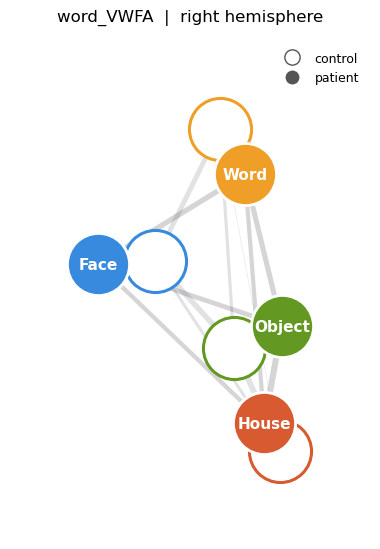

face_FFA         r  ctrl n=36  pt n=12


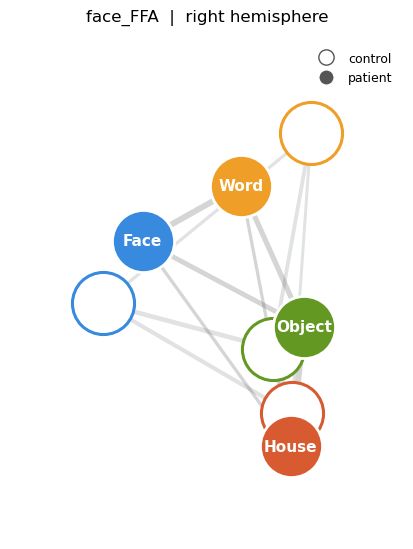

face_FFA         l  ctrl n=36  pt n=12


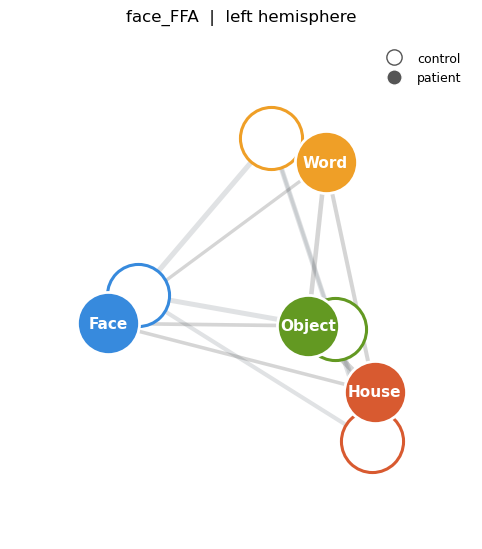

In [15]:
# ─── Procrustes/MDS configuration plots — selected ROI x hemi ────────────
def aligned_configs(s):
    cmats = list(subj_mats(s, 'control').values())
    pmats = list(subj_mats(s, 'patient').values())
    if len(cmats) < 2 or len(pmats) < 1:
        return None
    csim = np.nanmean(np.stack(cmats), axis=0)
    psim = np.nanmean(np.stack(pmats), axis=0)
    mtx1, mtx2, _ = procrustes(mds_coords(csim), mds_coords(psim))
    return csim, psim, mtx1, mtx2, len(cmats), len(pmats)


def plot_procrustes(roi, hemi):
    s = stratum(mds_df, roi, hemi)
    out = aligned_configs(s)
    if out is None:
        print(f'{roi} {hemi}: too few subjects to plot')
        return
    csim, psim, c_xy, p_xy, nc, npt = out
    print(f'{roi:16s} {hemi}  ctrl n={nc}  pt n={npt}')
    fig, ax = plt.subplots(figsize=(5.6, 5.6))
    ax.set_facecolor('white')
    for a, b in PAIRS6:
        i, j = CATS4.index(a), CATS4.index(b)
        r = np.clip(np.nan_to_num(csim[i, j]), 0, 1)
        ax.plot([c_xy[i, 0], c_xy[j, 0]], [c_xy[i, 1], c_xy[j, 1]], color='#9aa0a6',
                lw=0.4 + r * 5.5, alpha=0.30, solid_capstyle='round', zorder=1)
    for a, b in PAIRS6:
        i, j = CATS4.index(a), CATS4.index(b)
        r = np.clip(np.nan_to_num(psim[i, j]), 0, 1)
        ax.plot([p_xy[i, 0], p_xy[j, 0]], [p_xy[i, 1], p_xy[j, 1]], color='#444',
                lw=0.4 + r * 5.5, alpha=0.22, solid_capstyle='round', zorder=2)
    for k, cat in enumerate(CATS4):
        ax.scatter(*c_xy[k], s=2000, facecolor='white', edgecolor=CAT_COLORS[cat],
                   linewidth=2.2, zorder=4)
        ax.scatter(*p_xy[k], s=2000, facecolor=CAT_COLORS[cat], edgecolor='white',
                   linewidth=2.0, zorder=5)
        ax.annotate(cat.capitalize(), p_xy[k], fontsize=11, fontweight='bold',
                    color='white', ha='center', va='center', zorder=6)
    ax.set_title(f'{roi}  |  {HEMIS[hemi]} hemisphere', fontsize=12, pad=14)
    ax.set_aspect('equal'); ax.axis('off')
    pad = 0.35
    allxy = np.vstack([c_xy, p_xy])
    ax.set_xlim(allxy[:, 0].min() - pad, allxy[:, 0].max() + pad)
    ax.set_ylim(allxy[:, 1].min() - pad, allxy[:, 1].max() + pad)
    legend = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
                         markeredgecolor='#555', markersize=11, label='control'),
              plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#555',
                         markersize=11, label='patient')]
    ax.legend(handles=legend, loc='upper right', frameon=False, fontsize=9)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'procrustes_{roi}_{hemi}.png', dpi=300, bbox_inches='tight')
    plt.show()


SELECTED = [('word_VWFA', 'r'), ('face_FFA', 'r'), ('face_FFA', 'l')]
for roi, hemi in SELECTED:
    plot_procrustes(roi, hemi)

## 10 · TFCE — surviving clusters, Table 2, surface figure
`TFCE_DIR` is the ComBat-harmonized run (set in Config). `tstat1` = ctrl > pt, `tstat2` = pt > ctrl; FWE p < .05 via `rand_tfce_corrp_tstat{N} > 0.95`, 10k permutations. Clusters are discovered from the files, so the figure legend and the table cannot disagree with what survived.

In [16]:
# ─── TFCE setup ──────────────────────────────────────────────────────────
import nibabel as nib
from nilearn import plotting
from scipy import ndimage

CORRP_PATTERN = 'rand_tfce_corrp_tstat{tstat}.nii.gz'
TSTAT_PATTERN = 'rand_tstat{tstat}.nii.gz'
DIRECTION     = {1: 'ctrl>pt', 2: 'pt>ctrl'}

# Reporting floor: 0 reports every surviving voxel. TFCE was chosen because it
# needs no cluster-forming threshold, and corrp > 0.95 is already voxel-level
# FWE, so an extent floor adds no error control. Keep at 0 unless the
# manuscript states otherwise.
MIN_VOX = 0

# Rendering floor: connected components smaller than this are omitted from the
# surface figure only. A handful of voxels cannot be localised on an inflated
# surface and renders as visual noise; the table still reports them. State the
# value in the figure caption, not the Methods.
MIN_VOX_RENDER = 30

print('TFCE_DIR:', TFCE_DIR, '| exists:', TFCE_DIR.exists())
print(f'MIN_VOX (table) = {MIN_VOX}   MIN_VOX_RENDER (figure) = {MIN_VOX_RENDER}')
if TFCE_DIR.exists():
    print('contents:', sorted(p.name for p in TFCE_DIR.iterdir())[:12])

TFCE_DIR: /user_data/csimmon2/sym_pt/group_results/tfce_votc_harmonized | exists: True
MIN_VOX (table) = 0   MIN_VOX_RENDER (figure) = 30
contents: ['comparison_with_without.csv', 'face_l_pt_vs_ctrl', 'face_r_pt_vs_ctrl', 'harmonized_subject_maps', 'house_l_pt_vs_ctrl', 'house_r_pt_vs_ctrl', 'object_l_pt_vs_ctrl', 'object_r_pt_vs_ctrl', 'tfce_summary.BAK_20260809.csv', 'tfce_summary.csv', 'votc_l_mask.nii.gz', 'votc_r_mask.nii.gz']


In [17]:
# ─── Discover surviving clusters (no hardcoded list) ─────────────────────
rows = []
for cat in CATEGORIES:
    for hemi in ('l', 'r'):
        test_dir = TFCE_DIR / f'{cat}_{hemi}_pt_vs_ctrl'
        if not test_dir.exists():
            continue
        for tstat in (1, 2):
            fc = test_dir / CORRP_PATTERN.format(tstat=tstat)
            ft = test_dir / TSTAT_PATTERN.format(tstat=tstat)
            if not fc.exists():
                continue
            corrp_img = nib.load(fc)
            corrp = corrp_img.get_fdata()
            sig = corrp > 0.95
            n_vox = int(sig.sum())
            if n_vox == 0:
                continue
            if ft.exists():
                tvals = nib.load(ft).get_fdata()
                masked_t = np.where(sig, tvals, -np.inf)
                peak_ijk = np.unravel_index(np.argmax(masked_t), masked_t.shape)
                peak_t = float(tvals[peak_ijk])
                peak_mni = nib.affines.apply_affine(corrp_img.affine, peak_ijk)
                peak_pfwe = float(1 - corrp[peak_ijk])
            else:
                peak_t = np.nan; peak_mni = (np.nan,) * 3; peak_pfwe = np.nan
            rows.append(dict(category=cat, hemi=hemi, tstat=tstat,
                             direction=DIRECTION[tstat], n_vox=n_vox,
                             mm3=n_vox * 8, peak_t=peak_t, peak_pfwe=peak_pfwe,
                             x=peak_mni[0], y=peak_mni[1], z=peak_mni[2]))

clusters = pd.DataFrame(rows).sort_values('n_vox', ascending=False).reset_index(drop=True)
print(f'Surviving clusters (FWE p<.05), MIN_VOX={MIN_VOX}:')
print(clusters.round(2).to_string(index=False))

reportable = clusters[clusters['n_vox'] >= MIN_VOX].copy()
below = clusters[clusters['n_vox'] < MIN_VOX]
if len(below):
    print('\nBelow MIN_VOX and therefore excluded from figures/tables:')
    print(below[['category', 'hemi', 'direction', 'n_vox']].to_string(index=False))

CLUSTER_LIST = [(r.category, r.hemi, int(r.tstat),
                 f'{r.category}_{r.hemi.upper()}  {r.direction}')
                for r in reportable.itertuples()]
print('\nGAINS  (pt>ctrl):', [(c, h, t) for c, h, t, _ in CLUSTER_LIST if t == 2])
print('LOSSES (ctrl>pt):', [(c, h, t) for c, h, t, _ in CLUSTER_LIST if t == 1])

Surviving clusters (FWE p<.05), MIN_VOX=0:
category hemi  tstat direction  n_vox   mm3  peak_t  peak_pfwe     x     y     z
  object    l      1   ctrl>pt   1295 10360    4.87       0.00 -54.0 -70.0  -4.0
   house    r      1   ctrl>pt    759  6072    3.92       0.01  30.0 -42.0  -6.0
    word    r      2   pt>ctrl    463  3704    6.46       0.00  48.0 -64.0  -8.0
   house    l      1   ctrl>pt    153  1224    4.07       0.01 -30.0 -46.0  -4.0
  object    r      1   ctrl>pt     54   432    3.86       0.03  34.0 -56.0 -10.0

GAINS  (pt>ctrl): [('word', 'r', 2)]
LOSSES (ctrl>pt): [('object', 'l', 1), ('house', 'r', 1), ('house', 'l', 1), ('object', 'r', 1)]


In [18]:
# ─── BH-FDR across the 8 category x hemisphere comparisons ───────────────
# TFCE gives voxel-level FWE within each test. The reported family is the
# 8 category x hemisphere comparisons, so peak p_FWE values are then
# BH-corrected across all 8 (not just the ones that survived FWE).
# Tests with no surviving voxel enter the family with p_FWE = 1.0.

FAMILY = [(c, h) for c in CATEGORIES for h in ('l', 'r')]

fam_rows = []
for cat, hemi in FAMILY:
    hit = clusters[(clusters.category == cat) & (clusters.hemi == hemi)]
    if len(hit):
        best = hit.loc[hit['peak_pfwe'].idxmin()]
        fam_rows.append(dict(category=cat, hemi=hemi, direction=best.direction,
                             n_vox=int(best.n_vox), peak_t=best.peak_t,
                             p_fwe=float(best.peak_pfwe)))
    else:
        fam_rows.append(dict(category=cat, hemi=hemi, direction='—',
                             n_vox=0, peak_t=np.nan, p_fwe=1.0))
fam = pd.DataFrame(fam_rows)

m = len(fam)
fam = fam.sort_values('p_fwe').reset_index(drop=True)
fam['rank'] = np.arange(1, m + 1)
fam['bh_crit'] = fam['rank'] * 0.05 / m
q, run = np.empty(m), 1.0
for i in range(m - 1, -1, -1):
    run = min(run, fam.loc[i, 'p_fwe'] * m / (i + 1))
    q[i] = run
fam['q_fdr'] = q
fam['survives_fdr'] = fam['q_fdr'] < 0.05

print(f'BH-FDR family: {m} category x hemisphere comparisons, q < .05')
print(fam[['category', 'hemi', 'direction', 'n_vox', 'peak_t',
           'p_fwe', 'rank', 'bh_crit', 'q_fdr', 'survives_fdr']]
      .round(5).to_string(index=False))

REPORTABLE = fam[fam['survives_fdr']][['category', 'hemi', 'direction', 'n_vox']]
print(f'\nReportable ({len(REPORTABLE)}):')
print(REPORTABLE.to_string(index=False))

BH-FDR family: 8 category x hemisphere comparisons, q < .05
category hemi direction  n_vox  peak_t  p_fwe  rank  bh_crit   q_fdr  survives_fdr
  object    l   ctrl>pt   1295 4.87149 0.0001     1  0.00625 0.00080          True
    word    r   pt>ctrl    463 6.46099 0.0044     2  0.01250 0.01653          True
   house    l   ctrl>pt    153 4.07453 0.0062     3  0.01875 0.01653          True
   house    r   ctrl>pt    759 3.92368 0.0085     4  0.02500 0.01700          True
  object    r   ctrl>pt     54 3.86209 0.0256     5  0.03125 0.04096          True
    face    l         —      0     NaN 1.0000     6  0.03750 1.00000         False
    face    r         —      0     NaN 1.0000     7  0.04375 1.00000         False
    word    l         —      0     NaN 1.0000     8  0.05000 1.00000         False

Reportable (5):
category hemi direction  n_vox
  object    l   ctrl>pt   1295
    word    r   pt>ctrl    463
   house    l   ctrl>pt    153
   house    r   ctrl>pt    759
  object    r   ctrl>

In [19]:
# ─── Table 2 values + Harvard-Oxford labels at each peak ─────────────────
from nilearn import datasets as nl_datasets

ho = nl_datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
ho_img = ho.maps if isinstance(ho.maps, nib.Nifti1Image) else nib.load(ho.maps)
ho_data = ho_img.get_fdata()

# % of OTC uses the per-hemisphere VOTC mask voxel counts
otc_n = {}
for hemi in ('l', 'r'):
    f = TFCE_DIR / f'votc_{hemi}_mask.nii.gz'
    otc_n[hemi] = int((nib.load(f).get_fdata() > 0.5).sum()) if f.exists() else np.nan
print('VOTC mask voxels:', otc_n)

out = []
for r in reportable.itertuples():
    ijk = np.round(nib.affines.apply_affine(np.linalg.inv(ho_img.affine),
                                            (r.x, r.y, r.z))).astype(int)
    try:
        label = ho.labels[int(ho_data[tuple(ijk)])]
    except (IndexError, ValueError):
        label = 'n/a'
    out.append(dict(cluster=f'{r.category}_{r.hemi.upper()}', contrast=r.direction,
                    vox=r.n_vox, mm3=r.mm3,
                    pct_otc=round(100 * r.n_vox / otc_n[r.hemi], 1) if otc_n[r.hemi] else np.nan,
                    peak_mni=f'[{r.x:.0f},{r.y:.0f},{r.z:.0f}]',
                    peak_t=round(r.peak_t, 2), p_fwe=round(r.peak_pfwe, 4),
                    ho_label=label))
table2 = pd.DataFrame(out)
print()
print(table2.to_string(index=False))
table2.to_csv(FIG_DIR / 'table2_tfce_clusters.csv', index=False)

VOTC mask voxels: {'l': 11340, 'r': 11540}

 cluster contrast  vox   mm3  pct_otc     peak_mni  peak_t  p_fwe                                    ho_label
object_L  ctrl>pt 1295 10360     11.4 [-54,-70,-4]    4.87 0.0001 Lateral Occipital Cortex, inferior division
 house_R  ctrl>pt  759  6072      6.6  [30,-42,-6]    3.92 0.0085                               Lingual Gyrus
  word_R  pt>ctrl  463  3704      4.0  [48,-64,-8]    6.46 0.0044 Lateral Occipital Cortex, inferior division
 house_L  ctrl>pt  153  1224      1.3 [-30,-46,-4]    4.07 0.0062                               Lingual Gyrus
object_R  ctrl>pt   54   432      0.5 [34,-56,-10]    3.86 0.0256          Temporal Occipital Fusiform Cortex


GAINS_FDR : [('word', 'r', 2)]
LOSSES_FDR: [('object', 'l', 1), ('house', 'l', 1), ('house', 'r', 1), ('object', 'r', 1)]


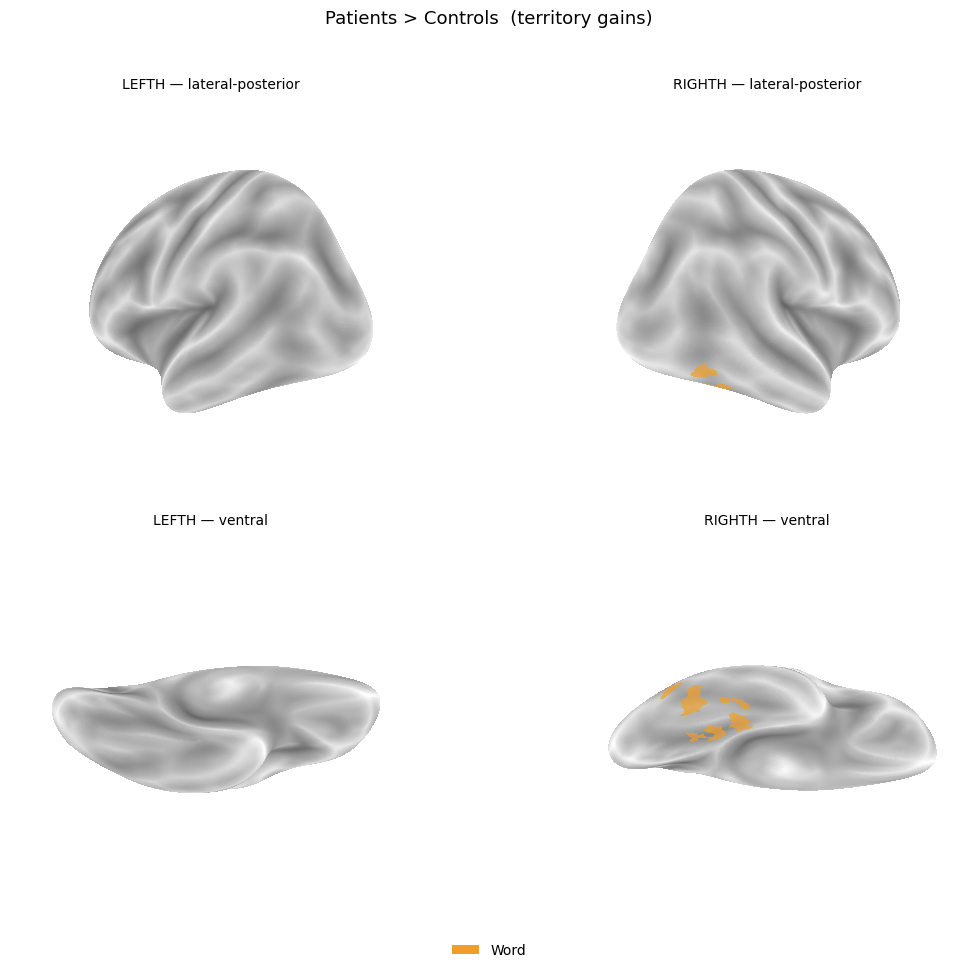

  omitted from render (< 30 vox, still reportable):
    word_R pt>ctrl: components of [27, 7, 1]


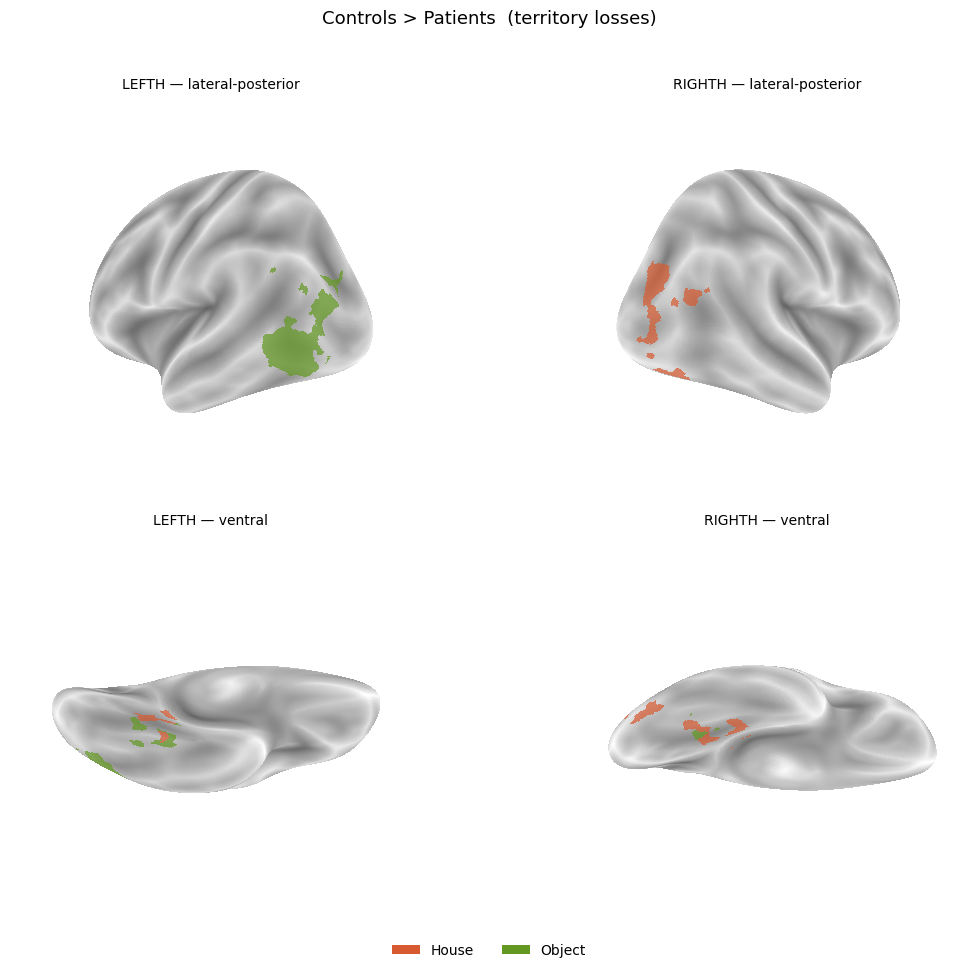

  omitted from render (< 30 vox, still reportable):
    house_L ctrl>pt: components of [16, 1]


In [20]:
# ─── TFCE clusters on inflated surfaces ──────────────────────────────────
# Plots only clusters surviving BH-FDR across the 8 category x hemisphere
# comparisons (cell above). Requires REPORTABLE.
#
# Inflated surface, vol_to_surf kind='line' / interpolation='linear',
# vertex threshold 0.3. Connected components below MIN_VOX_RENDER are omitted
# from the render only: a handful of voxels cannot be localised on an inflated
# surface and shows as visual noise. Those voxels survive FWE and remain in
# Table 2, so the floor is a visibility choice and belongs in the figure
# caption, not the Methods.
from matplotlib.colors import ListedColormap
from nilearn import surface
from nilearn.plotting import plot_surf_roi

CAT_INT   = {'face': 1, 'house': 2, 'object': 3, 'word': 4}
TSTAT_FOR = {'ctrl>pt': 1, 'pt>ctrl': 2}

GAINS_FDR  = [(r.category, r.hemi, TSTAT_FOR[r.direction])
              for r in REPORTABLE.itertuples() if r.direction == 'pt>ctrl']
LOSSES_FDR = [(r.category, r.hemi, TSTAT_FOR[r.direction])
              for r in REPORTABLE.itertuples() if r.direction == 'ctrl>pt']
print('GAINS_FDR :', GAINS_FDR)
print('LOSSES_FDR:', LOSSES_FDR)

VIEWS = {
    'l': [('lateral-posterior', 'lateral', (10, -150)),
          ('ventral',           'ventral', None)],
    'r': [('lateral-posterior', 'lateral', (10,  -30)),
          ('ventral',           'ventral', None)],
}

fsaverage = nl_datasets.fetch_surf_fsaverage(mesh='fsaverage')
cat_cmap = ListedColormap(['#cccccc'] + [CAT_COLORS[c] for c in CATEGORIES])


def project_clusters_to_surface(cluster_list, hemi, min_vox=MIN_VOX_RENDER,
                                report=None):
    """Combine clusters in one hemisphere into a single surface map.

    vertex value = CAT_INT for that category, 0 elsewhere. Connected components
    below min_vox are dropped from the render; if `report` is a list, each drop
    is appended to it as (category, hemi, direction, [component sizes]).
    """
    hemi_full = 'left' if hemi == 'l' else 'right'
    n_vert = surface.load_surf_mesh(fsaverage[f'infl_{hemi_full}'])[0].shape[0]
    out = np.zeros(n_vert, dtype=np.int16)
    for cat, h, tstat in cluster_list:
        if h != hemi:
            continue
        fpath = TFCE_DIR / f'{cat}_{h}_pt_vs_ctrl' / CORRP_PATTERN.format(tstat=tstat)
        vol_img = nib.load(fpath)
        sig = vol_img.get_fdata() > 0.95

        lab, n_comp = ndimage.label(sig)
        if n_comp:
            sizes = ndimage.sum(sig, lab, range(1, n_comp + 1))
            keep_ids = [i + 1 for i, s in enumerate(sizes) if s >= min_vox]
            dropped = sorted((int(s) for s in sizes if s < min_vox), reverse=True)
            keep = np.isin(lab, keep_ids) if keep_ids else np.zeros_like(sig)
        else:
            dropped, keep = [], np.zeros_like(sig)
        if report is not None and dropped:
            report.append((cat, h, DIRECTION[tstat], dropped))

        sig_img = nib.Nifti1Image(keep.astype(np.float32), vol_img.affine)
        surf_vals = surface.vol_to_surf(
            sig_img, fsaverage[f'pial_{hemi_full}'],
            radius=3.0, kind='line', interpolation='linear',
        )
        out[surf_vals > 0.3] = CAT_INT[cat]
    return out


for label, cluster_list, tag in [
        ('Patients > Controls  (territory gains)', GAINS_FDR,  'gains'),
        ('Controls > Patients  (territory losses)', LOSSES_FDR, 'losses')]:
    if not cluster_list:
        print(f'no FDR-surviving clusters for: {label}')
        continue
    present = [c for c in CATEGORIES if c in {x[0] for x in cluster_list}]
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw={'projection': '3d'})
    fig.suptitle(label, fontsize=13, y=0.98)

    dropped_report = []
    for col, (hemi, hemi_full) in enumerate([('l', 'left'), ('r', 'right')]):
        roi_map = project_clusters_to_surface(
            cluster_list, hemi, report=dropped_report).astype(float)
        for row, (view_label, view_named, view_custom) in enumerate(VIEWS[hemi]):
            plot_surf_roi(
                fsaverage[f'infl_{hemi_full}'], roi_map=roi_map,
                hemi=hemi_full, view=view_named,
                cmap=cat_cmap, vmin=0, vmax=4, threshold=0.5,
                bg_map=fsaverage[f'sulc_{hemi_full}'],
                bg_on_data=True, darkness=0.6,
                axes=axes[row, col], figure=fig,
            )
            if view_custom is not None:
                elev, azim = view_custom
                axes[row, col].view_init(elev=elev, azim=azim)
            axes[row, col].set_title(f'{hemi_full.upper()}H — {view_label}', fontsize=10)

    handles = [Patch(facecolor=CAT_COLORS[c], label=c.capitalize()) for c in present]
    fig.legend(handles=handles, loc='lower center', ncol=len(present),
               frameon=False, fontsize=10, bbox_to_anchor=(0.5, 0.02))
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    plt.savefig(FIG_DIR / f'tfce_surface_fdr_{tag}.png', dpi=300, bbox_inches='tight')
    plt.show()

    if dropped_report:
        print(f'  omitted from render (< {MIN_VOX_RENDER} vox, still reportable):')
        for cat, h, direc, sizes in dropped_report:
            print(f'    {cat}_{h.upper()} {direc}: components of {sizes}')

In [23]:
print('CATEGORIES:', list(CATEGORIES))
print('CAT_INT   :', CAT_INT)
for c in CATEGORIES:
    slot = list(CATEGORIES).index(c) + 1
    print(f'{c:7} CAT_INT={CAT_INT[c]}  cmap slot={slot}  '
          f'{"OK" if CAT_INT[c] == slot else "MISMATCH"}')

CATEGORIES: ['face', 'house', 'object', 'word']
CAT_INT   : {'face': 1, 'house': 2, 'object': 3, 'word': 4}
face    CAT_INT=1  cmap slot=1  OK
house   CAT_INT=2  cmap slot=2  OK
object  CAT_INT=3  cmap slot=3  OK
word    CAT_INT=4  cmap slot=4  OK


## 11 · QC — not a manuscript figure
Significant t-stats on the standard brain, one row per surviving cluster. Per-cluster t range is narrow, so `vmax` is set per panel; colorbars are not comparable across rows.

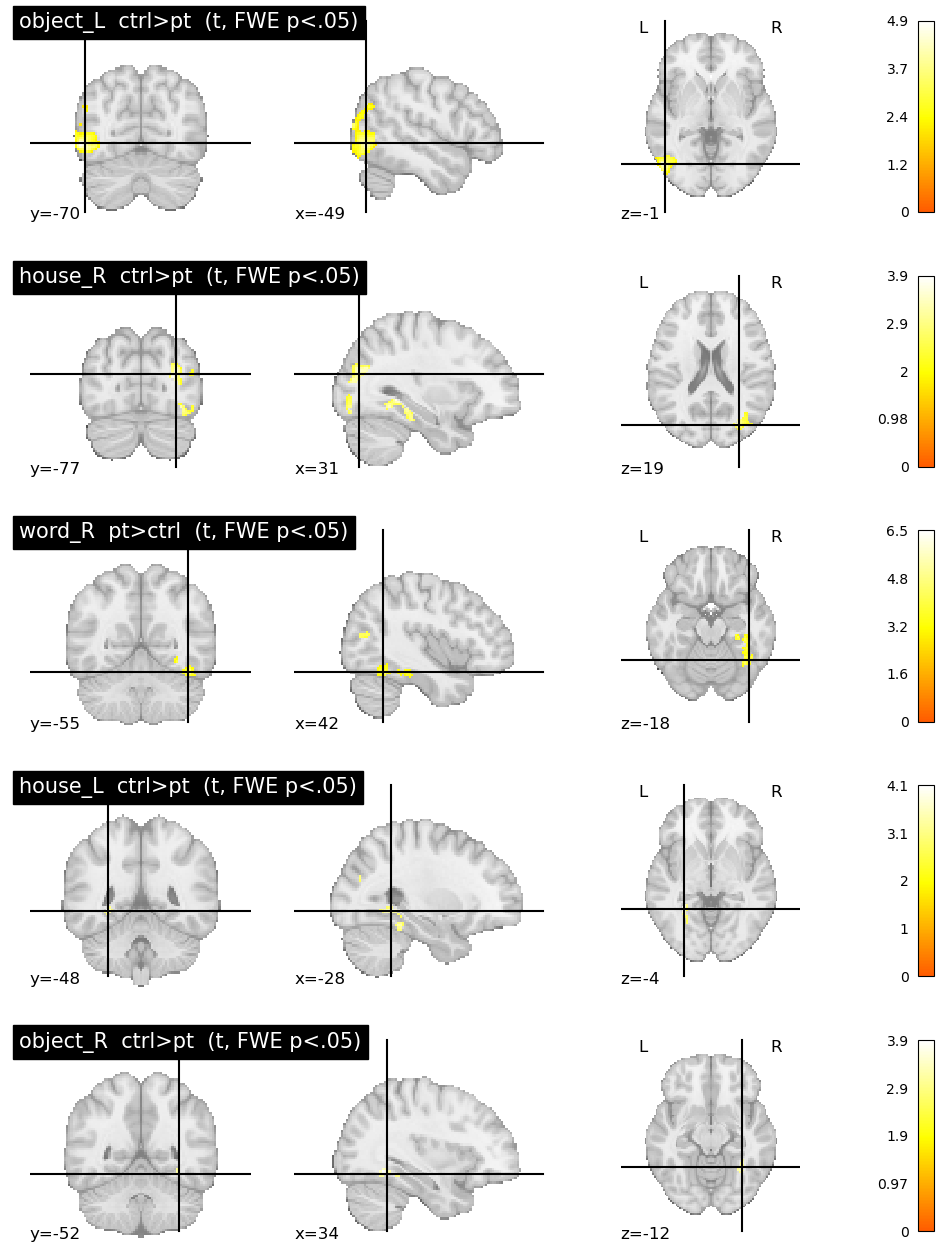

In [21]:
# ─── QC: FWE-significant t-stats on the standard brain (ortho cuts) ──────
n = len(CLUSTER_LIST)
fig, axes = plt.subplots(n, 1, figsize=(12, 3.2 * n))
axes = np.atleast_1d(axes)
for ax, (cat, hemi, tstat, title) in zip(axes, CLUSTER_LIST):
    test_dir = TFCE_DIR / f'{cat}_{hemi}_pt_vs_ctrl'
    corrp_img = nib.load(test_dir / CORRP_PATTERN.format(tstat=tstat))
    tstat_img = nib.load(test_dir / TSTAT_PATTERN.format(tstat=tstat))
    tstat_data = tstat_img.get_fdata() * (corrp_img.get_fdata() > 0.95)
    masked = nib.Nifti1Image(tstat_data, tstat_img.affine)
    vmax = float(tstat_data.max()) if tstat_data.max() > 0 else 1.0
    plotting.plot_stat_map(masked, threshold=0.01, display_mode='ortho',
                           colorbar=True, cmap='hot', vmax=vmax,
                           title=f'{title}  (t, FWE p<.05)', axes=ax)
plt.show()

# Play ground

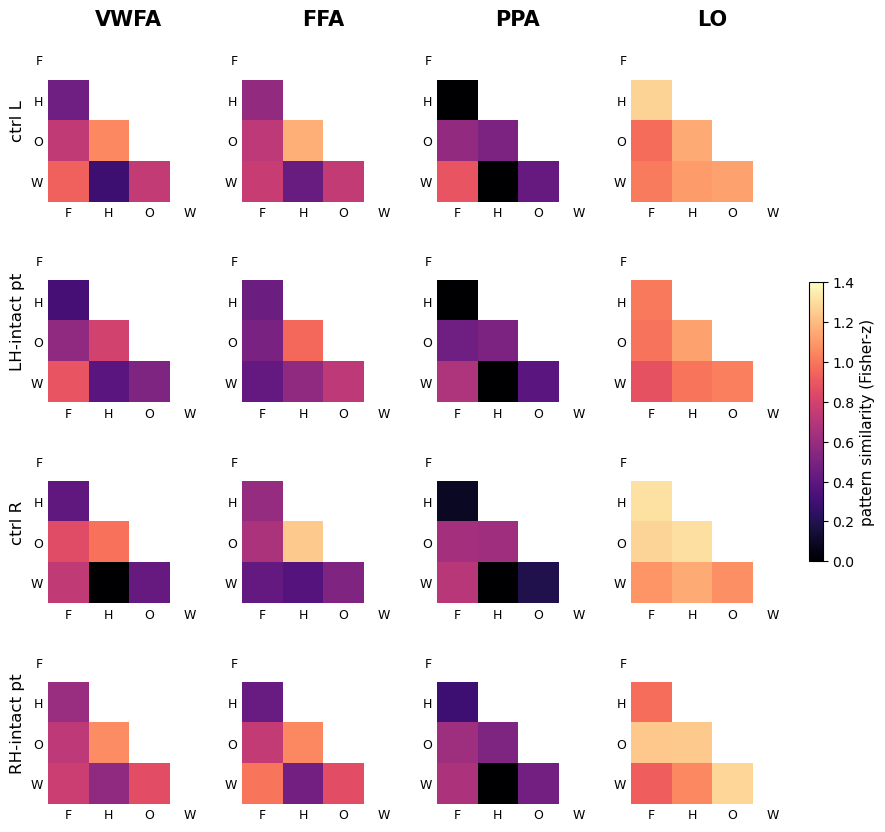

In [27]:
# =========================================================================
# CELL 1 · Absolute similarity matrices, four groups x four ROIs
# Conventional RSM display: what the six pairs actually look like.
# =========================================================================
from matplotlib.colors import TwoSlopeNorm
 
CAT_LBL = [c[0].upper() for c in CATEGORIES]
NC = len(CATEGORIES)
 
PAIR_IJ = {}
for i, a in enumerate(CATEGORIES):
    for j, b in enumerate(CATEGORIES):
        if i < j:
            PAIR_IJ[f'{a}-{b}'] = PAIR_IJ[f'{b}-{a}'] = (i, j)
 
 
def _mean_matrix(df, roi, hemi, intact=None):
    """Group-mean 4x4 Fisher-z matrix; lower triangle filled, rest NaN."""
    d = df[(df['category'] == roi) & (df['hemi'] == hemi)]
    if intact is not None:
        d = d[d['intact_hemi'] == intact]
    M = np.full((NC, NC), np.nan)
    for pair, g in d.groupby('pair'):
        if pair in PAIR_IJ:
            i, j = PAIR_IJ[pair]
            M[max(i, j), min(i, j)] = g['fisher_r'].mean()
    return M
 
 
ROWS_ABS = [('ctrl L',        lambda roi: _mean_matrix(rsa_c_long, roi, 'l')),
            ('LH-intact pt',  lambda roi: _mean_matrix(rsa_p_long, roi, 'l', 'left')),
            ('ctrl R',        lambda roi: _mean_matrix(rsa_c_long, roi, 'r')),
            ('RH-intact pt',  lambda roi: _mean_matrix(rsa_p_long, roi, 'r', 'right'))]
 
ROIS_RSM = [r for r in ROI_ORDER if r in set(rsa_c_long['category'])]
vmin, vmax = 0.0, 1.4
 
fig, axes = plt.subplots(len(ROWS_ABS), len(ROIS_RSM),
                         figsize=(2.5 * len(ROIS_RSM), 2.5 * len(ROWS_ABS)))
fig.patch.set_facecolor('white')
for r, (rlab, fn) in enumerate(ROWS_ABS):
    for c, roi in enumerate(ROIS_RSM):
        ax = axes[r, c]
        im = ax.imshow(fn(roi), cmap='magma', vmin=vmin, vmax=vmax)
        ax.set_xticks(range(NC)); ax.set_xticklabels(CAT_LBL, fontsize=9)
        ax.set_yticks(range(NC)); ax.set_yticklabels(CAT_LBL, fontsize=9)
        ax.tick_params(length=0)
        for sp in ax.spines.values():
            sp.set_visible(False)
        if r == 0:
            ax.set_title(ROI_TITLE.get(roi, roi), fontsize=15,
                         fontweight='bold', pad=10)
        if c == 0:
            ax.set_ylabel(rlab, fontsize=12)
cb = fig.colorbar(im, ax=axes, fraction=0.018, pad=0.02)
cb.set_label('pattern similarity (Fisher-z)', fontsize=11)
fig.savefig(FIG_DIR / 'rsm_absolute.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

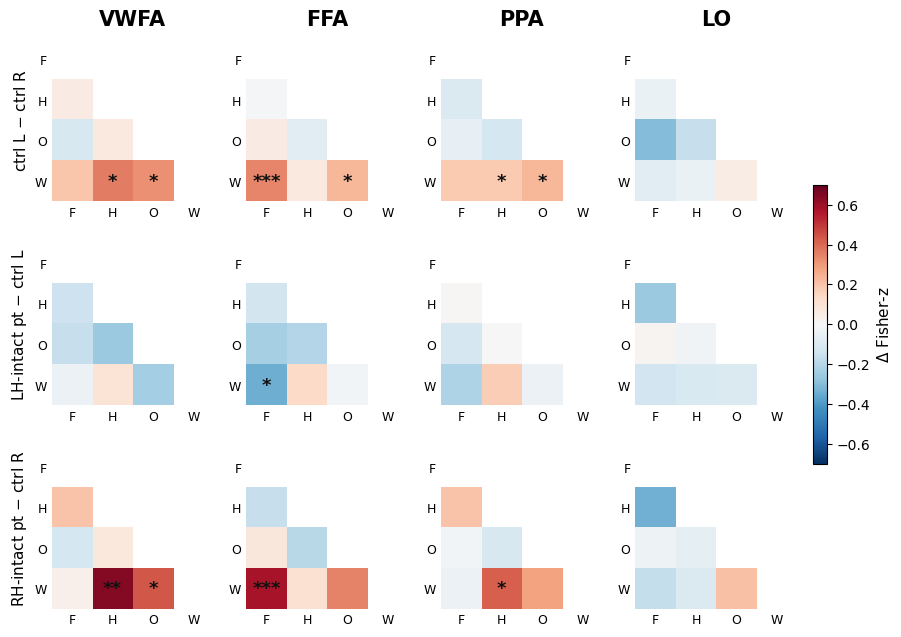

In [29]:
# =========================================================================
# CELL 2 · Difference matrices with FDR markers
# One row per comparison the manuscript reports, so the panels map onto the
# per-pair tests. Asterisks come straight from the stats file.
# =========================================================================
_g = STATS[STATS['measure'] == 'geometry'].copy()


def _q_lookup(model_suffix):
    """{(roi, pair): q} for one comparison, from the packed `model` column."""
    d = _g[_g['model'].str.endswith(model_suffix)]
    out = {}
    for r in d.itertuples():
        roi = r.model[:-(len(model_suffix) + 1)]
        out[(roi, r.level)] = r.q_fdr
    return out


def _omni_lookup(model_suffix):
    d = _g[(_g['model'].str.endswith(model_suffix)) & (_g['comparison'] == 'omnibus')]
    return {r.model[:-(len(model_suffix) + 1)]: r.omnibus_p for r in d.itertuples()}


ROWS_DIFF = [
    ('ctrl L $-$ ctrl R',
     lambda roi: _mean_matrix(rsa_c_long, roi, 'l') - _mean_matrix(rsa_c_long, roi, 'r'),
     _q_lookup('ctrl_LvsR'), _omni_lookup('ctrl_LvsR')),
    ('LH-intact pt $-$ ctrl L',
     lambda roi: _mean_matrix(rsa_p_long, roi, 'l', 'left') - _mean_matrix(rsa_c_long, roi, 'l'),
     _q_lookup('LH-intact_pt_vs_ctrl'), _omni_lookup('LH-intact_pt_vs_ctrl')),
    ('RH-intact pt $-$ ctrl R',
     lambda roi: _mean_matrix(rsa_p_long, roi, 'r', 'right') - _mean_matrix(rsa_c_long, roi, 'r'),
     _q_lookup('RH-intact_pt_vs_ctrl'), _omni_lookup('RH-intact_pt_vs_ctrl')),
]

lim = 0.7
fig, axes = plt.subplots(len(ROWS_DIFF), len(ROIS_RSM),
                         figsize=(2.5 * len(ROIS_RSM), 2.5 * len(ROWS_DIFF)))
fig.patch.set_facecolor('white')
for r, (rlab, fn, QL, OM) in enumerate(ROWS_DIFF):
    for c, roi in enumerate(ROIS_RSM):
        ax = axes[r, c]
        D = fn(roi)
        im = ax.imshow(D, cmap='RdBu_r',
                       norm=TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim))
        gate_open = OM.get(roi, np.nan) < .05
        for pair, (i, j) in PAIR_IJ.items():
            s = stars(QL.get((roi, pair))) if gate_open else ''
            if s:
                ax.text(min(i, j), max(i, j), s, ha='center', va='center',
                        fontsize=13, fontweight='bold', color='#111')
        ax.set_xticks(range(NC)); ax.set_xticklabels(CAT_LBL, fontsize=9)
        ax.set_yticks(range(NC)); ax.set_yticklabels(CAT_LBL, fontsize=9)
        ax.tick_params(length=0)
        for sp in ax.spines.values():
            sp.set_visible(False)
        if r == 0:
            ax.set_title(ROI_TITLE.get(roi, roi), fontsize=15,
                         fontweight='bold', pad=10)
        if c == 0:
            ax.set_ylabel(rlab, fontsize=11)
cb = fig.colorbar(im, ax=axes, fraction=0.018, pad=0.02)
cb.set_label('$\\Delta$ Fisher-z', fontsize=11)
fig.savefig(FIG_DIR / 'rsm_difference.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

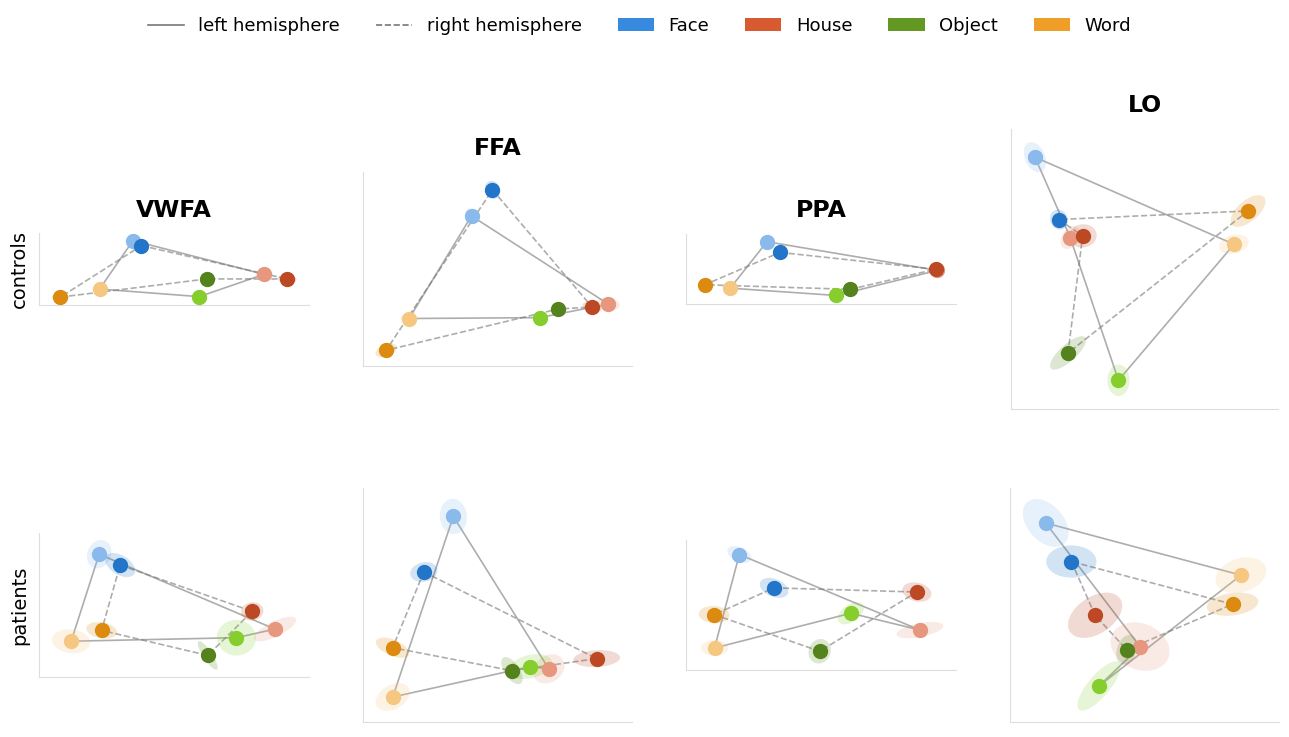

In [30]:
# =========================================================================
# CELL 3 · MDS, two rows: controls against each other, patients against
# each other. Requires the helpers from the four-group MDS cell
# (_subject_dissim, _classical_mds, _procrustes_align, ctrl_keys, pt_keys).
# =========================================================================
from matplotlib.patches import Ellipse

MDS_ROWS = [('controls', [('ctrl L', 'l', 'ctrl'), ('ctrl R', 'r', 'ctrl')]),
            ('patients', [('pt L',   'l', 'pt'),   ('pt R',   'r', 'pt')])]
ROW_STYLE = {'ctrl L': '-', 'pt L': '-', 'ctrl R': '--', 'pt R': '--'}
ROW_SHADE = {'ctrl L': 1.35, 'pt L': 1.35, 'ctrl R': 0.85, 'pt R': 0.85}

fig, axes = plt.subplots(2, len(ROIS_RSM),
                         figsize=(4.0 * len(ROIS_RSM), 8.0))
fig.patch.set_facecolor('white')
for r, (rlab, groups) in enumerate(MDS_ROWS):
    for c, roi in enumerate(ROIS_RSM):
        ax = axes[r, c]
        cfg = _group_configs(roi)
        ax.set_facecolor('white')
        for label, hemi, kind in groups:
            if label not in cfg:
                continue
            M, C = cfg[label]['mean'], cfg[label]['cov']
            loop = np.vstack([M, M[:1]])
            ax.plot(loop[:, 0], loop[:, 1], color='#777', lw=1.2,
                    ls=ROW_STYLE[label], alpha=0.6, zorder=1)
            for k, cat in enumerate(CATEGORIES):
                col = shade(CAT_COLORS[cat], ROW_SHADE[label])
                w, V = np.linalg.eigh(C[k])
                o = np.argsort(w)[::-1]
                ang = np.degrees(np.arctan2(V[1, o[0]], V[0, o[0]]))
                ax.add_patch(Ellipse(M[k], 2 * np.sqrt(max(w[o[0]], 0)),
                                     2 * np.sqrt(max(w[o[1]], 0)), angle=ang,
                                     facecolor=col, alpha=0.20,
                                     edgecolor='none', zorder=2))
                ax.plot(*M[k], 'o', ms=10, color=col, zorder=3)
        if r == 0:
            ax.set_title(ROI_TITLE.get(roi, roi), fontsize=17,
                         fontweight='bold', pad=12)
        if c == 0:
            ax.set_ylabel(rlab, fontsize=14)
        ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_color('#ddd')

handles = ([Line2D([], [], color='#777', lw=1.2, ls='-',  label='left hemisphere'),
            Line2D([], [], color='#777', lw=1.2, ls='--', label='right hemisphere')] +
           [Patch(facecolor=CAT_COLORS[c], label=c.capitalize()) for c in CATEGORIES])
fig.legend(handles=handles, loc='upper center', frameon=False,
           ncol=len(handles), bbox_to_anchor=(0.5, 1.04), fontsize=13)
fig.savefig(FIG_DIR / 'mds_two_row.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()